
## Usage Instructions

To run this pipeline:

1. **Update data paths** in Cell 5 to match your file locations
2. **Run cells sequentially** - each cell depends on previous ones
3. **Monitor progress** - training progress is displayed for each step
4. **Adjust parameters** if needed:
   - VAE architecture in cells 17, 24, 27
   - Training epochs and learning rates in trainer calls
   - Feature filtering parameters in Cell 8
   - Sparse autoencoder parameters in SAE training calls

The pipeline is designed to handle various data quality issues and will provide warnings when problems are detected. Results and trained models are automatically saved for future use.# Microbiome IBD Classification Pipeline with VAE+SAE Feature Engineering
*Adapted for metagenomics and metatranscriptomics data*

This notebook implements a comprehensive pipeline for IBD classification using Variational Autoencoders (VAE) and Sparse Autoencoders (SAE) for feature engineering on microbiome data.




## Cell 1: Imports and Setup


In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import umap
import biom
from qiime2 import Metadata
from gemelli.preprocessing import matrix_rclr
import os
import time
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

import qiime2 as q2
from qiime2 import Artifact, Metadata, Visualization
from qiime2.plugins.sample_classifier.pipelines import classify_samples, heatmap

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


All libraries imported successfully!
PyTorch version: 1.12.1
CUDA available: False



## Cell 2: Helper Functions


In [2]:
def get_device():
    """Get the appropriate device for computation"""
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using MPS (Metal Performance Shaders) device")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print("Using CUDA device")
    else:
        device = torch.device("cpu")
        print("Using CPU device")
    return device

def add_noise(data, noise_factor=0.05):
    """Add noise to input data for regularization"""
    noise = torch.randn_like(data) * noise_factor * data.std()
    return data + noise

def plot_training_curves(train_losses, val_losses=None, title="Training Curves"):
    """Plot training and validation loss curves"""
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss', alpha=0.7)
    if val_losses is not None and len(val_losses) > 0:
        plt.plot(val_losses, label='Validation Loss', alpha=0.7)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Initialize device
device = get_device()
print(f"Device initialized: {device}")


Using MPS (Metal Performance Shaders) device
Device initialized: mps


## Cell 3: Taxonomy Helper Functions


In [3]:
def find_ogu_by_species(taxonomy_df, species_name, feature_data):
    """Find OGU IDs corresponding to a given species name"""
    matching_ogus = []
    for ogu_id in taxonomy_df.index:
        if ogu_id in feature_data.columns:
            taxon = taxonomy_df.loc[ogu_id, 'taxonomy']
            if species_name.lower() in taxon.lower():
                matching_ogus.append(ogu_id)
    return matching_ogus

def get_taxonomy_info(ogu_id, taxonomy_df):
    """Get full taxonomy information for an OGU ID"""
    if ogu_id in taxonomy_df.index:
        return taxonomy_df.loc[ogu_id, 'taxonomy']
    return "Unknown taxonomy"

def extract_species_name(taxonomy_string):
    """Extract species name from taxonomy string"""
    if 's__' in taxonomy_string:
        # Get the species part after 's__'
        species_part = taxonomy_string.split('s__')[-1]
        # Remove any trailing taxonomic levels and clean up
        species = species_part.split(';')[0].strip()
        if species and species != '' and species != 'unclassified' and species != 'unidentified':
            return species
    
    # If no species, try genus
    if 'g__' in taxonomy_string:
        genus_part = taxonomy_string.split('g__')[-1]
        genus = genus_part.split(';')[0].strip()
        if genus and genus != '' and genus != 'unclassified' and genus != 'unidentified':
            return f"genus_{genus}"
    
    # If no genus, try family
    if 'f__' in taxonomy_string:
        family_part = taxonomy_string.split('f__')[-1]
        family = family_part.split(';')[0].strip()
        if family and family != '' and family != 'unclassified' and family != 'unidentified':
            return f"family_{family}"
    
    return None

def format_feature_name(feature_id, taxonomy_df=None):
    """Format feature name to show both OGU ID and species/genus/family name"""
    if taxonomy_df is not None and feature_id in taxonomy_df.index:
        taxonomy = taxonomy_df.loc[feature_id, 'taxonomy']
        species_name = extract_species_name(taxonomy)
        if species_name:
            return f"{feature_id} ({species_name})"
    return feature_id

def get_taxonomic_level(taxonomy_string, level='species'):
    """Extract specific taxonomic level from taxonomy string"""
    level_prefixes = {
        'domain': 'd__',
        'phylum': 'p__',
        'class': 'c__', 
        'order': 'o__',
        'family': 'f__',
        'genus': 'g__',
        'species': 's__'
    }
    
    if level in level_prefixes:
        prefix = level_prefixes[level]
        if prefix in taxonomy_string:
            level_part = taxonomy_string.split(prefix)[-1]
            return level_part.split(';')[0].strip()
    
    return "unclassified"

print("Taxonomy helper functions defined successfully!")


Taxonomy helper functions defined successfully!



## Cell 4: Data Processor Class



In [4]:
class MicrobiomeDataProcessor:
    """Class to handle microbiome data loading and preprocessing"""
    
    def __init__(self, data_paths):
        self.data_paths = data_paths
        self.device = device
        
    def load_data(self):
        """Load microbiome data from biom files and metadata"""
        print("Loading microbiome data...")
        
        # Load biom tables
        self.table_metag = biom.load_table(self.data_paths['metag_biom'])
        self.table_metaT = biom.load_table(self.data_paths['metat_biom'])
        
        # Convert to dataframes
        self.table_metag_df = self.table_metag.to_dataframe().T
        self.table_metaT_df = self.table_metaT.to_dataframe().T
        
        # Load metadata
        self.metadata = Metadata.load(self.data_paths['metadata'])
        self.metadata_df = self.metadata.to_dataframe()
        
        # Load lineages if available
        if 'lineages' in self.data_paths:
            self.lineages = pd.read_csv(self.data_paths['lineages'], sep='\t', header=None)
            self.lineages.columns = ['genome_id', 'taxonomy']
            self.process_taxonomy()
        
        print(f"MetaG shape: {self.table_metag_df.shape}")
        print(f"MetaT shape: {self.table_metaT_df.shape}")
        print(f"Metadata shape: {self.metadata_df.shape}")
        print(f"Diagnosis distribution:\n{self.metadata_df['diagnosis'].value_counts()}")
        
    def process_taxonomy(self):
        """Process taxonomy information for features"""
        metag_features = list(self.table_metag_df.columns)
        metaT_features = list(self.table_metaT_df.columns)
        
        # Filter for features in the data
        self.metag_taxonomy = self.lineages[self.lineages['genome_id'].isin(metag_features)]
        self.metaT_taxonomy = self.lineages[self.lineages['genome_id'].isin(metaT_features)]
        
        print(f"MetaG features with taxonomy: {len(self.metag_taxonomy)}")
        print(f"MetaT features with taxonomy: {len(self.metaT_taxonomy)}")
        
    def apply_rclr_transformation(self, pseudocount=1e-6):
        """Apply robust CLR transformation using gemelli with pseudocount"""
        print(f"Applying RCLR transformation with pseudocount: {pseudocount}...")
        
        # Apply RCLR to metagenomics data
        table_metag_array = self.table_metag.matrix_data.toarray().T
        table_metag_array_pseudo = table_metag_array + pseudocount
        self.table_metag_rclr = pd.DataFrame(
            matrix_rclr(table_metag_array_pseudo),
            index=self.table_metag.ids('sample'),
            columns=self.table_metag.ids('observation')
        )
        
        # Apply RCLR to metatranscriptomics data
        table_metaT_array = self.table_metaT.matrix_data.toarray().T
        table_metaT_array_pseudo = table_metaT_array + pseudocount
        self.table_metaT_rclr = pd.DataFrame(
            matrix_rclr(table_metaT_array_pseudo),
            index=self.table_metaT.ids('sample'),
            columns=self.table_metaT.ids('observation')
        )
        
        print(f"MetaG RCLR shape: {self.table_metag_rclr.shape}")
        print(f"MetaT RCLR shape: {self.table_metaT_rclr.shape}")
        
    def filter_features(self, min_prevalence=0.1, top_variance_pct=0.20):
        """Filter features based on prevalence and variance"""
        print(f"Filtering features (min_prevalence={min_prevalence}, top_variance={top_variance_pct})...")
        
        # Filter MetaG features
        metag_prevalence = (self.table_metag_rclr != 0).mean(axis=0)
        metag_filtered = self.table_metag_rclr.loc[:, metag_prevalence >= min_prevalence]
        
        # Keep top variance features
        metag_variance = metag_filtered.var(axis=0)
        top_n = int(len(metag_variance) * top_variance_pct)
        metag_top_features = metag_variance.nlargest(top_n).index
        self.table_metag_filtered = metag_filtered[metag_top_features]
        
        # Filter MetaT features
        metaT_prevalence = (self.table_metaT_rclr != 0).mean(axis=0)
        metaT_filtered = self.table_metaT_rclr.loc[:, metaT_prevalence >= min_prevalence]
        
        # Keep top variance features
        metaT_variance = metaT_filtered.var(axis=0)
        top_n = int(len(metaT_variance) * top_variance_pct)
        metaT_top_features = metaT_variance.nlargest(top_n).index
        self.table_metaT_filtered = metaT_filtered[metaT_top_features]
        
        print(f"MetaG features after filtering: {self.table_metag_filtered.shape[1]}")
        print(f"MetaT features after filtering: {self.table_metaT_filtered.shape[1]}")
        
    def prepare_datasets(self):
        """Prepare datasets for training"""
        print("Preparing datasets...")
        
        # Find common samples
        metag_samples = set(self.table_metag_filtered.index)
        metaT_samples = set(self.table_metaT_filtered.index)
        metadata_samples = set(self.metadata_df.index)
        
        self.common_samples = metag_samples.intersection(metaT_samples).intersection(metadata_samples)
        print(f"Common samples: {len(self.common_samples)}")
        
        # Filter to common samples
        self.metag_data = self.table_metag_filtered.loc[self.common_samples]
        self.metaT_data = self.table_metaT_filtered.loc[self.common_samples]
        self.labels = self.metadata_df.loc[self.common_samples, 'diagnosis']
        
        # Encode labels
        self.label_encoder = LabelEncoder()
        self.encoded_labels = self.label_encoder.fit_transform(self.labels)
        self.label_names = self.label_encoder.classes_
        
        print(f"Label distribution after encoding:")
        for i, label in enumerate(self.label_names):
            count = np.sum(self.encoded_labels == i)
            print(f"  {label}: {count}")
        
        # Scale features
        self.scaler_metag = StandardScaler()
        self.scaler_metaT = StandardScaler()
        
        self.metag_scaled = self.scaler_metag.fit_transform(self.metag_data)
        self.metaT_scaled = self.scaler_metaT.fit_transform(self.metaT_data)
        
        # Create combined dataset for multiomic analysis
        self.combined_data = np.concatenate([self.metag_scaled, self.metaT_scaled], axis=1)
        
        print(f"MetaG scaled shape: {self.metag_scaled.shape}")
        print(f"MetaT scaled shape: {self.metaT_scaled.shape}")
        print(f"Combined shape: {self.combined_data.shape}")

print("MicrobiomeDataProcessor class defined successfully!")


MicrobiomeDataProcessor class defined successfully!



## Cell 5: Define Data Paths and Initialize Processor


In [5]:
# Data paths - update these according to your file locations
data_paths = {
    'metag_biom': 'data/metaG/222424_72996_analysis_Metagenomic_Woltkav014DatabasescratchqpwoltkaWoLr2WoLr2BIOMnonebiom.biom',
    'metat_biom': 'data/metaT/222425_72996_analysis_Metatranscriptomic_Woltkav014DatabasescratchqpwoltkaWoLr2WoLr2BIOMnonebiom.biom',
    'metadata': 'data/metadata/72996_72996_analysis_mapping.txt',
    'lineages': 'data/lineages.txt'
}

# Initialize the data processor
processor = MicrobiomeDataProcessor(data_paths)
print("Data processor initialized successfully!")
print("Ready to load data...")


Data processor initialized successfully!
Ready to load data...



## Cell 6: Load and Process Data


In [6]:

# Load all the data
processor.load_data()



Loading microbiome data...


MetaG features with taxonomy: 10616
MetaT features with taxonomy: 2111
MetaG shape: (1592, 10616)
MetaT shape: (741, 2111)
Metadata shape: (1592, 383)
Diagnosis distribution:
CD        735
UC        444
nonIBD    413
Name: diagnosis, dtype: int64


## Cell 7: Apply RCLR Transformation


In [7]:

# Apply robust CLR transformation
processor.apply_rclr_transformation()


Applying RCLR transformation with pseudocount: 1e-06...
MetaG RCLR shape: (1592, 10616)
MetaT RCLR shape: (741, 2111)



## Cell 8: Filter Features


In [8]:

# Filter features based on prevalence and variance
processor.filter_features(min_prevalence=0.1, top_variance_pct=0.20)

Filtering features (min_prevalence=0.1, top_variance=0.2)...
MetaG features after filtering: 2123
MetaT features after filtering: 422



## Cell 9: Prepare Datasets


In [9]:

# Prepare the final datasets
processor.prepare_datasets()


Preparing datasets...
Common samples: 741
Label distribution after encoding:
  CD: 341
  UC: 212
  nonIBD: 188
MetaG scaled shape: (741, 2123)
MetaT scaled shape: (741, 422)
Combined shape: (741, 2545)


## Cell 10: VAE Model Definition


In [10]:

class MicrobiomeVAE(nn.Module):
    """Enhanced VAE for microbiome data with sparsity handling"""
    
    def __init__(self, input_dim, hidden_dims=[512, 256, 128], latent_dim=50, dropout_rate=0.3):
        super(MicrobiomeVAE, self).__init__()
        
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        # Encoder
        encoder_layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            encoder_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.LeakyReLU(0.2),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim
            
        self.encoder = nn.Sequential(*encoder_layers)
        
        # Latent projections
        self.fc_mu = nn.Linear(hidden_dims[-1], latent_dim)
        self.fc_var = nn.Linear(hidden_dims[-1], latent_dim)
        
        # Decoder
        decoder_layers = []
        prev_dim = latent_dim
        
        for hidden_dim in reversed(hidden_dims):
            decoder_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.LeakyReLU(0.2),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim
            
        decoder_layers.append(nn.Linear(hidden_dims[0], input_dim))
        self.decoder = nn.Sequential(*decoder_layers)
        
        # Input normalization
        self.input_norm = nn.LayerNorm(input_dim)
        
        # Initialize weights properly
        self._initialize_weights()
        
    def _initialize_weights(self):
        """Initialize model weights to prevent NaN losses"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.1)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
        
    def encode(self, x):
        x = self.input_norm(x)
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_var(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

def microbiome_vae_loss(recon_x, x, mu, logvar, beta=1.0, alpha=0.05):
    """Loss function optimized for microbiome data with stability checks"""
    # Reconstruction loss (MSE)
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    
    # KL divergence with clamping to prevent explosion
    logvar = torch.clamp(logvar, -10, 10)  # Clamp logvar to prevent overflow
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    # L1 regularization on latent space for sparsity
    l1_loss = alpha * torch.mean(torch.abs(mu))
    
    total_loss = recon_loss + beta * kl_loss + l1_loss
    
    # Check for NaN and return a large finite value if found
    if torch.isnan(total_loss) or torch.isinf(total_loss):
        print("Warning: NaN or Inf detected in loss, returning fallback loss")
        total_loss = torch.tensor(1e6, device=total_loss.device, requires_grad=True)
        recon_loss = torch.tensor(1e6, device=recon_loss.device)
        kl_loss = torch.tensor(0.0, device=kl_loss.device)
        l1_loss = torch.tensor(0.0, device=l1_loss.device)
    
    return total_loss, recon_loss, kl_loss, l1_loss

print("VAE model and loss function defined successfully!")


VAE model and loss function defined successfully!



## Cell 11: Sparse Autoencoder Model


In [11]:

class SparseAutoencoder(nn.Module):
    """Sparse Autoencoder for feature extraction"""
    
    def __init__(self, latent_dim, sparse_dim, l1_reg=0.001):
        super(SparseAutoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(latent_dim, sparse_dim),
            nn.ReLU(),
            nn.BatchNorm1d(sparse_dim)
        )
        
        self.decoder = nn.Linear(sparse_dim, latent_dim)
        self.l1_reg = l1_reg
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
    def get_sparse_features(self, x):
        return self.encoder(x)

def sparse_loss(y_true, y_pred, model, l1_reg=0.001):
    """Loss function for sparse autoencoder"""
    mse_loss = F.mse_loss(y_pred, y_true)
    l1_loss = l1_reg * torch.sum(torch.abs(model.encoder[0].weight))
    return mse_loss + l1_loss

print("Sparse Autoencoder model and loss function defined successfully!")

Sparse Autoencoder model and loss function defined successfully!



## Cell 12: VAE Trainer Class


In [12]:

class MicrobiomeVAETrainer:
    """Trainer class for microbiome VAE"""
    
    def __init__(self, model, device, lr=1e-4):
        self.model = model
        self.device = device
        self.optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
        
        # Initialize model weights properly
        self._initialize_weights()
        
    def _initialize_weights(self):
        """Initialize model weights properly to avoid NaN losses"""
        for m in self.model.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.1)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def train_epoch(self, train_loader, beta=0.01, alpha=0.001, noise_factor=0.01):
        self.model.train()
        total_loss = 0
        valid_batches = 0
        
        for batch_idx, data in enumerate(train_loader):
            data = data[0].to(self.device)
            
            # Skip batches with NaN/inf
            if torch.isnan(data).any() or torch.isinf(data).any():
                continue
            
            # Very small noise to avoid destabilizing training    
            noisy_data = data + torch.randn_like(data) * noise_factor * 0.1
            
            self.optimizer.zero_grad()
            recon_batch, mu, logvar = self.model(noisy_data)
            
            # Skip if model outputs are invalid
            if (torch.isnan(recon_batch).any() or torch.isinf(recon_batch).any() or
                torch.isnan(mu).any() or torch.isinf(mu).any() or
                torch.isnan(logvar).any() or torch.isinf(logvar).any()):
                continue
            
            loss, recon_loss, kl_loss, l1_loss = microbiome_vae_loss(
                recon_batch, data, mu, logvar, beta, alpha
            )
            
            if torch.isnan(loss) or torch.isinf(loss):
                continue
            
            loss.backward()
            
            # Check for valid gradients
            valid_grads = True
            for param in self.model.parameters():
                if param.grad is not None:
                    if torch.isnan(param.grad).any() or torch.isinf(param.grad).any():
                        valid_grads = False
                        break
            
            if not valid_grads:
                continue
            
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 0.1)
            self.optimizer.step()
            
            total_loss += loss.item()
            valid_batches += 1
        
        if valid_batches == 0:
            print("Warning: No valid batches in this epoch!")
            return float('inf')
            
        return total_loss / valid_batches
    
    def validate(self, val_loader, beta=0.01, alpha=0.001):
        self.model.eval()
        total_loss = 0
        valid_batches = 0
        
        with torch.no_grad():
            for data in val_loader:
                data = data[0].to(self.device)
                
                if torch.isnan(data).any() or torch.isinf(data).any():
                    continue
                    
                recon_batch, mu, logvar = self.model(data)
                
                if (torch.isnan(recon_batch).any() or torch.isinf(recon_batch).any() or
                    torch.isnan(mu).any() or torch.isinf(mu).any() or
                    torch.isnan(logvar).any() or torch.isinf(logvar).any()):
                    continue
                
                loss, _, _, _ = microbiome_vae_loss(
                    recon_batch, data, mu, logvar, beta, alpha
                )
                
                if not torch.isnan(loss) and not torch.isinf(loss):
                    total_loss += loss.item()
                    valid_batches += 1
        
        if valid_batches == 0:
            return float('inf')
            
        return total_loss / valid_batches
    
    def train(self, train_loader, val_loader, epochs=100, patience=15, 
              beta=0.01, alpha=0.001, noise_factor=0.01):
        """Train the VAE with very conservative parameters"""
        
        train_losses = []
        val_losses = []
        best_val_loss = float('inf')
        patience_counter = 0
        model_saved = False
        
        print(f"Training VAE for {epochs} epochs with very conservative parameters...")
        start_time = time.time()
        
        for epoch in range(1, epochs + 1):
            train_loss = self.train_epoch(train_loader, beta, alpha, noise_factor)
            val_loss = self.validate(val_loader, beta, alpha)
            
            # Handle infinite losses
            if train_loss == float('inf') or val_loss == float('inf'):
                print(f"Infinite loss at epoch {epoch}, stopping training")
                break
            
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            
            if epoch % 10 == 0 or epoch == 1:
                print(f'Epoch {epoch}: Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')
            
            # Early stopping with improvement threshold
            improvement_threshold = 0.0001
            if val_loss < best_val_loss - improvement_threshold:
                best_val_loss = val_loss
                patience_counter = 0
                # Save the best model
                model_path = f'best_vae_model_{self.model.input_dim}.pt'
                torch.save(self.model.state_dict(), model_path)
                model_saved = True
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch}')
                break
        
        # Load best model if it was saved
        if model_saved:
            model_path = f'best_vae_model_{self.model.input_dim}.pt'
            if os.path.exists(model_path):
                self.model.load_state_dict(torch.load(model_path))
                print("Loaded best model weights")
            else:
                print("Warning: Best model file not found, using current weights")
        else:
            print("Warning: No model was saved due to training issues")
        
        training_time = time.time() - start_time
        print(f"Training completed in {training_time:.2f} seconds")
        
        return train_losses, val_losses

print("VAE Trainer class defined successfully!")

VAE Trainer class defined successfully!



## Cell 13: Feature Extractor Class


In [13]:

class FeatureExtractor:
    """Extract features using trained VAE and Sparse Autoencoder"""
    
    def __init__(self, vae_model, device):
        self.vae_model = vae_model
        self.device = device
        
    def get_latent_features(self, data):
        """Extract latent features from VAE"""
        self.vae_model.eval()
        
        if isinstance(data, np.ndarray):
            data_tensor = torch.FloatTensor(data).to(self.device)
        else:
            data_tensor = data.to(self.device)
        
        dataset = TensorDataset(data_tensor)
        loader = DataLoader(dataset, batch_size=64)
        
        latent_vectors = []
        with torch.no_grad():
            for batch in loader:
                batch_data = batch[0]
                mu, _ = self.vae_model.encode(batch_data)
                latent_vectors.append(mu.cpu().numpy())
        
        return np.vstack(latent_vectors)
    
    def train_sparse_autoencoder(self, latent_features, sparse_multiplier=3, 
                               epochs=50, l1_reg=0.001):
        """Train sparse autoencoder on latent features with robust NaN handling"""
        
        # Check input features for validity
        if np.isnan(latent_features).any() or np.isinf(latent_features).any():
            print("Warning: Input latent features contain NaN or inf values!")
            # Remove NaN/inf rows
            valid_rows = ~(np.isnan(latent_features).any(axis=1) | np.isinf(latent_features).any(axis=1))
            latent_features = latent_features[valid_rows]
            print(f"Using {valid_rows.sum()} valid samples out of {len(valid_rows)}")
            
            if latent_features.shape[0] < 10:
                print("Error: Too few valid samples for sparse autoencoder training")
                return []
        
        latent_dim = latent_features.shape[1]
        sparse_dim = latent_dim * sparse_multiplier
        
        print(f"Training sparse autoencoder: {latent_dim} -> {sparse_dim}")
        
        sparse_ae = SparseAutoencoder(latent_dim, sparse_dim, l1_reg).to(self.device)
        optimizer = optim.Adam(sparse_ae.parameters(), lr=1e-4)  # Lower learning rate
        
        latent_tensor = torch.FloatTensor(latent_features).to(self.device)
        dataset = TensorDataset(latent_tensor)
        loader = DataLoader(dataset, batch_size=32, shuffle=True)
        
        losses = []
        valid_epochs = 0
        
        for epoch in range(1, epochs + 1):
            sparse_ae.train()
            epoch_loss = 0
            valid_batches = 0
            
            for batch_data in loader:
                data = batch_data[0]
                
                # Skip invalid batches
                if torch.isnan(data).any() or torch.isinf(data).any():
                    continue
                
                optimizer.zero_grad()
                reconstructed = sparse_ae(data)
                
                # Skip if reconstruction is invalid
                if torch.isnan(reconstructed).any() or torch.isinf(reconstructed).any():
                    continue
                
                loss = sparse_loss(data, reconstructed, sparse_ae, l1_reg)
                
                if torch.isnan(loss) or torch.isinf(loss):
                    continue
                
                loss.backward()
                
                # Check gradients
                valid_grads = True
                for param in sparse_ae.parameters():
                    if param.grad is not None:
                        if torch.isnan(param.grad).any() or torch.isinf(param.grad).any():
                            valid_grads = False
                            break
                
                if not valid_grads:
                    continue
                
                torch.nn.utils.clip_grad_norm_(sparse_ae.parameters(), 1.0)
                optimizer.step()
                
                epoch_loss += loss.item()
                valid_batches += 1
            
            if valid_batches > 0:
                epoch_loss /= valid_batches
                losses.append(epoch_loss)
                valid_epochs += 1
                
                if epoch % 10 == 0 or epoch == 1:
                    print(f'Sparse AE Epoch {epoch}: Loss: {epoch_loss:.6f}')
            else:
                print(f'Sparse AE Epoch {epoch}: No valid batches')
                losses.append(float('inf'))
        
        if valid_epochs == 0:
            print("Error: Sparse autoencoder training failed completely")
            return []
        
        self.sparse_ae = sparse_ae
        print(f"Sparse autoencoder training completed with {valid_epochs} valid epochs")
        return losses
    
    def get_sparse_features(self, latent_features):
        """Extract sparse features with validation"""
        # Check input validity
        if np.isnan(latent_features).any() or np.isinf(latent_features).any():
            print("Warning: Input latent features contain NaN/inf, cleaning...")
            # Replace NaN/inf with zeros or small values
            latent_features = np.nan_to_num(latent_features, nan=0.0, posinf=1.0, neginf=-1.0)
        
        self.sparse_ae.eval()
        latent_tensor = torch.FloatTensor(latent_features).to(self.device)
        
        with torch.no_grad():
            sparse_features = self.sparse_ae.get_sparse_features(latent_tensor)
        
        sparse_array = sparse_features.cpu().numpy()
        
        # Final validation - replace any remaining NaN/inf
        if np.isnan(sparse_array).any() or np.isinf(sparse_array).any():
            print("Warning: Sparse features contain NaN/inf, cleaning...")
            sparse_array = np.nan_to_num(sparse_array, nan=0.0, posinf=1.0, neginf=-1.0)
        
        return sparse_array
    
    def analyze_feature_importance(self, original_feature_names, taxonomy_df=None):
        """Analyze which original features are most important with taxonomy information"""
        
        try:
            # Get weights from sparse autoencoder decoder
            sparse_to_latent = self.sparse_ae.decoder.weight.data.cpu().numpy()
            
            # Get weights from VAE encoder - need to get the right layer
            # The issue is we need to trace back through the encoder properly
            
            # Get the mu projection weights (latent_dim x last_hidden_dim)
            latent_weights = self.vae_model.fc_mu.weight.data.cpu().numpy()
            
            # Get the last encoder layer weights
            encoder_layers = []
            for module in self.vae_model.encoder.modules():
                if isinstance(module, nn.Linear):
                    encoder_layers.append(module)
            
            if len(encoder_layers) == 0:
                print("Warning: Could not find encoder layers for feature importance analysis")
                return {}
                
            # Get the first encoder layer (input -> first hidden)
            first_encoder_weights = encoder_layers[0].weight.data.cpu().numpy()
            
            print(f"Debug shapes:")
            print(f"  Sparse to latent: {sparse_to_latent.shape}")  
            print(f"  Latent weights: {latent_weights.shape}")
            print(f"  First encoder: {first_encoder_weights.shape}")
            print(f"  Original features: {len(original_feature_names)}")
            
            # Check dimension compatibility
            expected_input_dim = first_encoder_weights.shape[1]
            if expected_input_dim != len(original_feature_names):
                print(f"Warning: Dimension mismatch!")
                print(f"  Expected input features: {expected_input_dim}")
                print(f"  Provided feature names: {len(original_feature_names)}")
                
                # Use only the features that match
                original_feature_names = original_feature_names[:expected_input_dim]
                print(f"  Using first {len(original_feature_names)} features")
            
            # For a simplified analysis, just use the first encoder layer weights
            # Each row represents a hidden unit, each column represents an input feature
            feature_importance = {}
            
            # For each sparse feature (decoder output)
            for sparse_idx in range(sparse_to_latent.shape[1]):
                # Get importance as the absolute sum of connections through the network
                # This is simplified - just use first encoder layer importance
                importance_scores = np.abs(first_encoder_weights).mean(axis=0)
                
                # Ensure we don't exceed array bounds
                max_features = min(len(importance_scores), len(original_feature_names))
                importance_scores = importance_scores[:max_features]
                feature_names = original_feature_names[:max_features]
                
                # Create feature importance dictionary with formatted names
                if taxonomy_df is not None:
                    feature_dict = {
                        format_feature_name(feature_name, taxonomy_df): importance_scores[j] 
                        for j, feature_name in enumerate(feature_names)
                    }
                else:
                    feature_dict = dict(zip(feature_names, importance_scores))
                
                feature_importance[sparse_idx] = sorted(feature_dict.items(), 
                                                    key=lambda x: x[1], reverse=True)
            
            return feature_importance
            
        except Exception as e:
            print(f"Error in feature importance analysis: {str(e)}")
            print("Returning empty feature importance dictionary")
            return {}

print("Feature Extractor class defined successfully!")

Feature Extractor class defined successfully!



## Cell 14: Classification Class


In [14]:
class Q2SampleClassifier:
    """QIIME2 Sample Classifier wrapper for IBD prediction with extensive debugging"""
    
    def __init__(self):
        self.results = None
        
    def sparse_features_to_biom_qza(self, sparse_features, sample_ids, feature_prefix="sparse_"):
        """Convert sparse features to QIIME2 artifact with debugging"""
        
        print(f"\n=== DEBUGGING BIOM/QZA CONVERSION ===")
        print(f"Input sparse_features shape: {sparse_features.shape}")
        print(f"Input sample_ids length: {len(sample_ids)}")
        print(f"Feature prefix: {feature_prefix}")
        
        # Create feature IDs
        feature_ids = [f"{feature_prefix}{i}" for i in range(sparse_features.shape[1])]
        print(f"Created {len(feature_ids)} feature IDs")
        print(f"First 5 feature IDs: {feature_ids[:5]}")
        print(f"First 5 sample IDs: {sample_ids[:5]}")
        
        # Debug sparse features statistics
        print(f"\nSparse features statistics:")
        print(f"  Min value: {sparse_features.min():.6f}")
        print(f"  Max value: {sparse_features.max():.6f}")
        print(f"  Mean: {sparse_features.mean():.6f}")
        print(f"  Std: {sparse_features.std():.6f}")
        print(f"  Zero values: {(sparse_features == 0).sum()} / {sparse_features.size}")
        print(f"  NaN values: {np.isnan(sparse_features).sum()}")
        print(f"  Inf values: {np.isinf(sparse_features).sum()}")
        
        # Create BIOM table
        print(f"\nCreating BIOM table...")
        print(f"Transposing features for BIOM: {sparse_features.T.shape}")
        
        biom_table = biom.Table(sparse_features.T, feature_ids, sample_ids)
        print(f"BIOM table created successfully")
        print(f"BIOM table shape: {biom_table.shape}")
        print(f"BIOM table feature count: {biom_table.length(axis='observation')}")
        print(f"BIOM table sample count: {biom_table.length(axis='sample')}")
        
        # Convert to DataFrame for inspection
        biom_table_df = biom_table.to_dataframe().T
        print(f"\nBIOM table as DataFrame:")
        print(f"DataFrame shape: {biom_table_df.shape}")
        print(f"DataFrame columns (first 5): {list(biom_table_df.columns[:5])}")
        print(f"DataFrame index (first 5): {list(biom_table_df.index[:5])}")
        print(f"DataFrame preview:")
        print(biom_table_df.iloc[:3, :3])
        
        # Convert to QIIME2 artifact
        print(f"\nConverting to QIIME2 artifact...")
        qza_artifact = Artifact.import_data('FeatureTable[Frequency]', biom_table)
        print(f"QZA artifact created: {qza_artifact}")
        print(f"QZA artifact type: {qza_artifact.type}")
        print(f"QZA artifact UUID: {qza_artifact.uuid}")
        
        # View QZA as DataFrame
        qza_artifact_df = qza_artifact.view(pd.DataFrame)
        print(f"\nQZA artifact as DataFrame:")
        print(f"QZA DataFrame shape: {qza_artifact_df.shape}")
        print(f"QZA DataFrame preview:")
        print(qza_artifact_df.iloc[:3, :3])
        
        print(f"=== BIOM/QZA CONVERSION COMPLETE ===\n")
        
        return qza_artifact, biom_table
    
    def train_and_evaluate(self, X_train, X_test, y_train, y_test, label_names, approach_name="features"):
        """Train and evaluate using QIIME2 sample classifier with extensive debugging"""
        
        print(f"\n{'='*60}")
        print(f"DEBUGGING Q2 SAMPLE CLASSIFIER - {approach_name.upper()}")
        print(f"{'='*60}")
        
        print(f"Input data shapes:")
        print(f"  X_train: {X_train.shape}")
        print(f"  X_test: {X_test.shape}")
        print(f"  y_train: {y_train.shape}")
        print(f"  y_test: {y_test.shape}")
        print(f"  label_names: {label_names}")
        
        print(f"\nLabel distribution:")
        print(f"  y_train unique: {np.unique(y_train, return_counts=True)}")
        print(f"  y_test unique: {np.unique(y_test, return_counts=True)}")
        
        print(f"Converting {approach_name} features to QIIME2 format...")
        
        # Combine train and test data for QIIME2 (it handles the split internally)
        X_combined = np.vstack([X_train, X_test])
        y_combined = np.hstack([y_train, y_test])
        
        print(f"\nCombined data:")
        print(f"  X_combined shape: {X_combined.shape}")
        print(f"  y_combined shape: {y_combined.shape}")
        print(f"  y_combined unique: {np.unique(y_combined, return_counts=True)}")
        
        # Create sample IDs
        train_samples = [f"train_sample_{i}" for i in range(len(X_train))]
        test_samples = [f"test_sample_{i}" for i in range(len(X_test))]
        all_sample_ids = train_samples + test_samples
        
        print(f"\nSample IDs:")
        print(f"  Total samples: {len(all_sample_ids)}")
        print(f"  First 5 sample IDs: {all_sample_ids[:5]}")
        print(f"  Last 5 sample IDs: {all_sample_ids[-5:]}")
        
        # Convert sparse features to BIOM/QZA format
        qza_table, biom_table = self.sparse_features_to_biom_qza(
            X_combined, all_sample_ids, f"{approach_name}_sparse_"
        )
        
        # Create metadata DataFrame
        print(f"\nCreating metadata DataFrame...")
        metadata_df = pd.DataFrame({
            'sample-id': all_sample_ids,
            'diagnosis': [label_names[label] for label in y_combined]
        })
        print(f"Metadata DataFrame before setting index:")
        print(f"  Shape: {metadata_df.shape}")
        print(f"  Columns: {list(metadata_df.columns)}")
        print(f"  First 5 rows:")
        print(metadata_df.head())
        print(f"  Diagnosis value counts:")
        print(metadata_df['diagnosis'].value_counts())
        
        metadata_df.set_index('sample-id', inplace=True)
        print(f"\nMetadata DataFrame after setting index:")
        print(f"  Shape: {metadata_df.shape}")
        print(f"  Index name: {metadata_df.index.name}")
        print(f"  First 5 index values: {list(metadata_df.index[:5])}")
        print(f"  Sample of metadata:")
        print(metadata_df.head())
        
        # Convert to QIIME2 Metadata
        print(f"\nConverting to QIIME2 Metadata...")
        try:
            q2_metadata = Metadata(metadata_df)
            print(f"QIIME2 Metadata created successfully")
            print(f"  Metadata columns: {q2_metadata.columns}")
            
            diagnosis_column = q2_metadata.get_column('diagnosis')
            print(f"Diagnosis column extracted:")
            print(f"  Column type: {type(diagnosis_column)}")
            print(f"  Column name: {diagnosis_column.name}")
            print(f"  Sample diagnosis column:")
            diagnosis_series = diagnosis_column.to_series()
            print(f"  Series shape: {diagnosis_series.shape}")
            print(f"  Series value counts:")
            print(diagnosis_series.value_counts())
            print(f"  First 5 diagnosis values: {list(diagnosis_series.head())}")
            
        except Exception as e:
            print(f"ERROR creating QIIME2 metadata: {str(e)}")
            raise e
        
        print(f"\nRunning QIIME2 sample classifier for {approach_name}...")
        print(f"Classification parameters:")
        print(f"  test_size: 0.2")
        print(f"  cv: 5")
        print(f"  random_state: 42")
        print(f"  n_estimators: 100")
        print(f"  estimator: GradientBoostingClassifier")
        print(f"  optimize_feature_selection: True")
        print(f"  parameter_tuning: True")
        
        try:
            # Run QIIME2 classify_samples
            results = classify_samples(
                table=qza_table,
                metadata=diagnosis_column,
                test_size=0.2,
                step=0.1,
                cv=5,
                random_state=42,
                n_estimators=100,
                estimator='GradientBoostingClassifier',
                optimize_feature_selection=True,
                parameter_tuning=True,
                palette='viridis',
                missing_samples='error'
            )
            
            self.results = results
            
            print(f"\n🎉 QIIME2 classification completed successfully for {approach_name}!")
            
            # Debug the results object
            print(f"\nDEBUGGING RESULTS OBJECT:")
            print(f"Results type: {type(results)}")
            print(f"Results attributes: {dir(results)}")
            
            # Extract and examine individual components
            print(f"\nExamining individual result components:")
            
            try:
                accuracy_results = results.accuracy_results
                print(f"  ✓ Accuracy results: {type(accuracy_results)} - {accuracy_results.uuid}")
            except Exception as e:
                print(f"  ✗ Accuracy results error: {e}")
                
            try:
                predictions = results.predictions
                print(f"  ✓ Predictions: {type(predictions)} - {predictions.uuid}")
                predictions_df = predictions.view(pd.DataFrame)
                print(f"    Predictions DataFrame shape: {predictions_df.shape}")
                print(f"    Predictions DataFrame columns: {list(predictions_df.columns)}")
                print(f"    Predictions preview:")
                print(predictions_df.head())
                print(f"    Prediction value counts:")
                print(predictions_df.iloc[:, 0].value_counts() if predictions_df.shape[1] > 0 else "No columns")
            except Exception as e:
                print(f"  ✗ Predictions error: {e}")
                
            try:
                feature_importance = results.feature_importance
                print(f"  ✓ Feature importance: {type(feature_importance)} - {feature_importance.uuid}")
                importance_df = feature_importance.view(pd.DataFrame)
                print(f"    Feature importance DataFrame shape: {importance_df.shape}")
                print(f"    Feature importance DataFrame columns: {list(importance_df.columns)}")
                print(f"    Top 5 important features:")
                print(importance_df.head())
            except Exception as e:
                print(f"  ✗ Feature importance error: {e}")
                
            try:
                sample_estimator = results.sample_estimator
                print(f"  ✓ Sample estimator: {type(sample_estimator)} - {sample_estimator.uuid}")
            except Exception as e:
                print(f"  ✗ Sample estimator error: {e}")
            
            try:
                probabilities = results.probabilities
                print(f"  ✓ Probabilities: {type(probabilities)} - {probabilities.uuid}")
                prob_df = probabilities.view(pd.DataFrame)
                print(f"    Probabilities DataFrame shape: {prob_df.shape}")
                print(f"    Probabilities DataFrame columns: {list(prob_df.columns)}")
                print(f"    Probabilities preview:")
                print(prob_df.head())
            except Exception as e:
                print(f"  ✗ Probabilities error: {e}")
            
            # Save results with debugging
            print(f"\nSaving results files...")
            try:
                results.accuracy_results.save(f'q2_accuracy_{approach_name}.qzv')
                print(f"  ✓ Saved: q2_accuracy_{approach_name}.qzv")
            except Exception as e:
                print(f"  ✗ Error saving accuracy: {e}")
                
            try:
                results.predictions.save(f'q2_predictions_{approach_name}.qzv')
                print(f"  ✓ Saved: q2_predictions_{approach_name}.qzv")
            except Exception as e:
                print(f"  ✗ Error saving predictions: {e}")
                
            try:
                results.feature_importance.save(f'q2_feature_importance_{approach_name}.qza')
                print(f"  ✓ Saved: q2_feature_importance_{approach_name}.qza")
            except Exception as e:
                print(f"  ✗ Error saving feature importance: {e}")
            
            # Create simplified results dictionary for compatibility
            results_dict = {
                'GradientBoostingClassifier': {
                    'model': results.sample_estimator,
                    'accuracy': 'See q2_accuracy_*.qzv file',
                    'f1_micro': 'See q2_accuracy_*.qzv file', 
                    'f1_macro': 'See q2_accuracy_*.qzv file',
                    'f1_weighted': 'See q2_accuracy_*.qzv file',
                    'predictions': results.predictions,
                    'qiime2_results': results
                }
            }
            
            print(f"\nResults dictionary created successfully!")
            print(f"Keys: {list(results_dict.keys())}")
            print(f"GBC keys: {list(results_dict['GradientBoostingClassifier'].keys())}")
            
            print(f"{'='*60}")
            print(f"Q2 SAMPLE CLASSIFIER DEBUG COMPLETE - SUCCESS")
            print(f"{'='*60}\n")
            
            return results_dict
            
        except Exception as e:
            print(f"\n❌ ERROR in QIIME2 classification: {str(e)}")
            print(f"Error type: {type(e)}")
            import traceback
            print(f"Traceback:")
            traceback.print_exc()
            
            return {
                'GradientBoostingClassifier': {
                    'model': None,
                    'accuracy': 0.0,
                    'f1_micro': 0.0,
                    'f1_macro': 0.0, 
                    'f1_weighted': 0.0,
                    'predictions': None,
                    'error': str(e)
                }
            }
    
    def create_heatmap(self, qza_table, feature_importance, sample_metadata, approach_name="features"):
        """Create QIIME2 heatmap visualization with debugging"""
        
        print(f"\n=== DEBUGGING HEATMAP CREATION - {approach_name.upper()} ===")
        print(f"Input parameters:")
        print(f"  qza_table type: {type(qza_table)}")
        print(f"  feature_importance type: {type(feature_importance)}")
        print(f"  sample_metadata type: {type(sample_metadata)}")
        print(f"  approach_name: {approach_name}")
        
        try:
            print(f"\nExamining QZA table...")
            qza_df = qza_table.view(pd.DataFrame)
            print(f"  QZA table shape: {qza_df.shape}")
            print(f"  QZA table columns (first 5): {list(qza_df.columns[:5])}")
            print(f"  QZA table index (first 5): {list(qza_df.index[:5])}")
            
            print(f"\nExamining feature importance...")
            importance_df = feature_importance.view(pd.DataFrame)
            print(f"  Feature importance shape: {importance_df.shape}")
            print(f"  Feature importance columns: {list(importance_df.columns)}")
            print(f"  Top 5 important features:")
            print(importance_df.head())
            
            print(f"\nExamining sample metadata...")
            metadata_series = sample_metadata.to_series()
            print(f"  Metadata series shape: {metadata_series.shape}")
            print(f"  Metadata value counts:")
            print(metadata_series.value_counts())
            
            print(f"\nCreating heatmap for {approach_name}...")
            
            heatmap_results = heatmap(
                table=qza_table,
                importance=feature_importance,
                sample_metadata=sample_metadata,
                feature_count=50,
                importance_threshold=0.00,
                group_samples=True,
                normalize=True,
                metric='euclidean',
                method='average',
                cluster='features',
                color_scheme='RdBu_r'
            )
            
            print(f"  ✓ Heatmap created successfully!")
            print(f"  Heatmap results type: {type(heatmap_results)}")
            print(f"  Heatmap attributes: {dir(heatmap_results)}")
            
            # Save heatmap
            heatmap_results.heatmap.save(f'q2_heatmap_{approach_name}.qzv')
            print(f"  ✓ Heatmap saved as q2_heatmap_{approach_name}.qzv")
            print(f"  Heatmap UUID: {heatmap_results.heatmap.uuid}")
            
            print(f"=== HEATMAP CREATION COMPLETE - SUCCESS ===\n")
            
            return heatmap_results
            
        except Exception as e:
            print(f"\n❌ Error creating heatmap: {str(e)}")
            print(f"Error type: {type(e)}")
            import traceback
            print(f"Traceback:")
            traceback.print_exc()
            print(f"=== HEATMAP CREATION COMPLETE - FAILED ===\n")
            return None

print("Q2SampleClassifier class with extensive debugging defined successfully!")
print("Debug features added:")
print("  ✓ Input data validation and statistics")
print("  ✓ BIOM table creation debugging")  
print("  ✓ QZA artifact conversion debugging")
print("  ✓ Metadata creation and validation")
print("  ✓ QIIME2 results examination")
print("  ✓ File saving verification")
print("  ✓ Error handling with full tracebacks")
print("  ✓ Heatmap creation debugging")

Q2SampleClassifier class with extensive debugging defined successfully!
Debug features added:
  ✓ Input data validation and statistics
  ✓ BIOM table creation debugging
  ✓ QZA artifact conversion debugging
  ✓ Metadata creation and validation
  ✓ QIIME2 results examination
  ✓ File saving verification
  ✓ Error handling with full tracebacks
  ✓ Heatmap creation debugging




## Cell 15: Visualization Functions


In [15]:
def visualize_latent_space(latent_vectors, labels, label_names, title="Latent Space"):
    """Visualize latent space with UMAP and t-SNE"""
    
    # UMAP
    print("Computing UMAP embedding...")
    umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    umap_embedding = umap_reducer.fit_transform(latent_vectors)
    
    # t-SNE
    print("Computing t-SNE embedding...")
    tsne_reducer = TSNE(n_components=2, perplexity=30, random_state=42)
    tsne_embedding = tsne_reducer.fit_transform(latent_vectors)
    
    # Create visualization DataFrame
    vis_df = pd.DataFrame({
        'UMAP_1': umap_embedding[:, 0],
        'UMAP_2': umap_embedding[:, 1],
        'tSNE_1': tsne_embedding[:, 0],
        'tSNE_2': tsne_embedding[:, 1],
        'Label': [label_names[l] for l in labels]
    })
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # UMAP
    for label in label_names:
        mask = vis_df['Label'] == label
        ax1.scatter(vis_df.loc[mask, 'UMAP_1'], vis_df.loc[mask, 'UMAP_2'], 
                   label=label, alpha=0.7, s=20)
    ax1.set_title(f'UMAP - {title}')
    ax1.set_xlabel('UMAP 1')
    ax1.set_ylabel('UMAP 2')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # t-SNE
    for label in label_names:
        mask = vis_df['Label'] == label
        ax2.scatter(vis_df.loc[mask, 'tSNE_1'], vis_df.loc[mask, 'tSNE_2'], 
                   label=label, alpha=0.7, s=20)
    ax2.set_title(f't-SNE - {title}')
    ax2.set_xlabel('t-SNE 1')
    ax2.set_ylabel('t-SNE 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return vis_df

print("Visualization functions defined successfully!")


Visualization functions defined successfully!


In [16]:
def map_sparse_features_to_otus(extractor, sparse_features, gene_names, approach_name="features"):
    """Map sparse features back to original OTUs/genes using the method from your example"""
    
    print(f"\n{'='*60}")
    print(f"MAPPING SPARSE FEATURES TO OTUs - {approach_name.upper()}")
    print(f"{'='*60}")
    
    # Calculate sparsity metrics
    sparsity = (sparse_features == 0).mean() * 100
    print(f"Sparsity of {approach_name} encoded features: {sparsity:.2f}%")
    
    # Get model weights
    sparse_ae_weights = extractor.sparse_ae.encoder[0].weight.data.cpu().numpy()
    vae_encoder_weights = extractor.vae_model.fc_mu.weight.data.cpu().numpy()
    sparse_dim = sparse_features.shape[1]
    
    print(f"Model architecture:")
    print(f"  Sparse AE encoder weights shape: {sparse_ae_weights.shape}")
    print(f"  VAE encoder (mu) weights shape: {vae_encoder_weights.shape}")
    print(f"  Sparse dimensions: {sparse_dim}")
    print(f"  Original gene/OTU count: {len(gene_names)}")
    
    print(f"Analyzing sparse feature importance...")
    
    # Calculate feature importance for each sparse feature
    feature_importance = {}
    for i in range(sparse_dim):
        # Get weights for this sparse feature (from sparse AE decoder)
        sparse_to_latent = extractor.sparse_ae.decoder.weight[:, i].cpu().detach().numpy()
        
        # Multiply with VAE encoder weights to get effect on original genes
        # This maps: sparse feature -> latent space -> original genes/OTUs
        gene_importance = np.abs(np.dot(vae_encoder_weights.T, sparse_to_latent))
        
        # Map to gene names
        feature_importance[i] = dict(zip(gene_names, gene_importance))
    
    # Find top genes/OTUs for each sparse feature
    top_genes_per_feature = {}
    for feature_idx, gene_scores in feature_importance.items():
        # Sort genes by importance score
        sorted_genes = sorted(gene_scores.items(), key=lambda x: x[1], reverse=True)
        # Keep top 10 genes/OTUs
        top_genes_per_feature[feature_idx] = sorted_genes[:10]
    
    # Calculate feature activations across samples
    feature_activations = sparse_features.mean(axis=0)
    top_activated_features = np.argsort(feature_activations)[-5:]
    
    print(f"\nTop OTUs/genes for most activated sparse features in {approach_name}:")
    for i, feature_idx in enumerate(top_activated_features):
        print(f"\nSparse feature {feature_idx} (activation: {feature_activations[feature_idx]:.4f}):")
        for gene, score in top_genes_per_feature[feature_idx]:
            print(f"  {gene}: {score:.4f}")
    
    # Calculate overall gene importance (weighted by activation)
    gene_overall_importance = {gene: 0 for gene in gene_names}
    for feature_idx, gene_scores in feature_importance.items():
        activation = feature_activations[feature_idx]
        for gene, score in gene_scores.items():
            gene_overall_importance[gene] += score * activation
    
    # Create importance dataframe
    sparse_importance_df = pd.DataFrame({
        'Gene_OTU': list(gene_overall_importance.keys()),
        'Sparse_AE_Importance': list(gene_overall_importance.values())
    })
    sparse_importance_df = sparse_importance_df.sort_values('Sparse_AE_Importance', ascending=False)
    
    print(f"\nTop 20 OTUs/genes by Sparse Autoencoder importance in {approach_name}:")
    print(sparse_importance_df.head(20))
    
    # Save results
    output_file = f'sparse_importance_{approach_name.lower()}.csv'
    sparse_importance_df.to_csv(output_file, index=False)
    print(f"Results saved to {output_file}")
    
    print(f"{'='*60}")
    print(f"SPARSE TO OTU MAPPING COMPLETE - {approach_name.upper()}")
    print(f"{'='*60}\n")
    
    return {
        'feature_importance': feature_importance,
        'top_genes_per_feature': top_genes_per_feature,
        'feature_activations': feature_activations,
        'sparse_importance_df': sparse_importance_df,
        'sparsity': sparsity
    }


## Cell 16: Metagenomics Analysis - Data Preparation


In [17]:
print("="*60)
print("METAGENOMICS ANALYSIS")
print("="*60)

# Prepare data loaders for MetaG
X_train_metag, X_test_metag, y_train, y_test = train_test_split(
    processor.metag_scaled, processor.encoded_labels, 
    test_size=0.2, random_state=42, stratify=processor.encoded_labels
)

print(f"MetaG training set shape: {X_train_metag.shape}")
print(f"MetaG test set shape: {X_test_metag.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test labels shape: {y_test.shape}")

# Create PyTorch tensors and data loaders
train_tensor = torch.FloatTensor(X_train_metag).to(device)
test_tensor = torch.FloatTensor(X_test_metag).to(device)

train_dataset = TensorDataset(train_tensor)
test_dataset = TensorDataset(test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

print("Data loaders created successfully!")


METAGENOMICS ANALYSIS
MetaG training set shape: (592, 2123)
MetaG test set shape: (149, 2123)
Training labels shape: (592,)
Test labels shape: (149,)
Data loaders created successfully!



## Cell 17: Metagenomics Analysis - Train VAE


Creating VAE with input dimension: 2123
VAE architecture created:
  Input dim: 2123
  Hidden dims: [512, 256, 128]
  Latent dim: 50


Training VAE for 100 epochs with very conservative parameters...
Epoch 1: Train Loss: 1.002809, Val Loss: 0.990026
Epoch 10: Train Loss: 1.003741, Val Loss: 80897.909375
Early stopping at epoch 16
Loaded best model weights
Training completed in 72.77 seconds


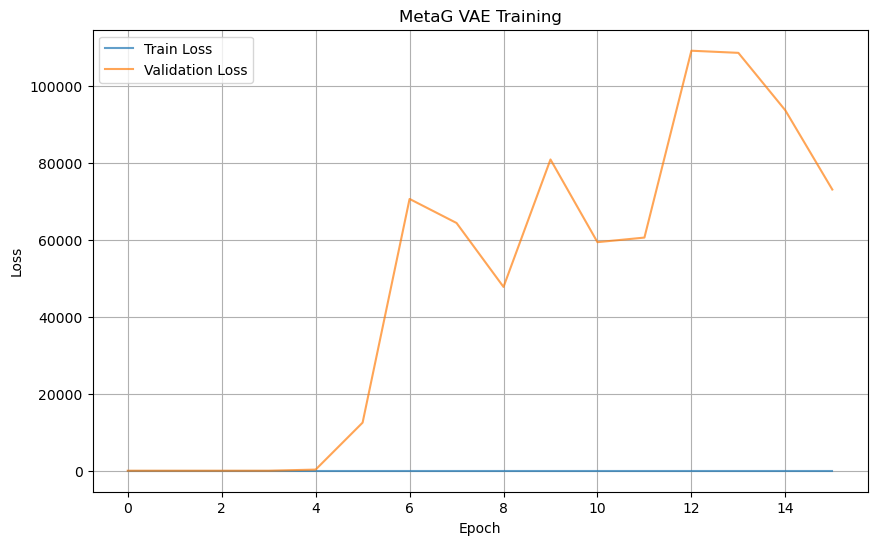

In [18]:
# Create and train VAE for MetaG
input_dim_metag = X_train_metag.shape[1]
print(f"Creating VAE with input dimension: {input_dim_metag}")

vae_metag = MicrobiomeVAE(input_dim_metag, hidden_dims=[512, 256, 128], 
                          latent_dim=50).to(device)

print(f"VAE architecture created:")
print(f"  Input dim: {input_dim_metag}")
print(f"  Hidden dims: [512, 256, 128]")
print(f"  Latent dim: 50")

# Train the VAE
trainer_metag = MicrobiomeVAETrainer(vae_metag, device)
train_losses, val_losses = trainer_metag.train(train_loader, test_loader, epochs=100)

# Plot training curves
plot_training_curves(train_losses, val_losses, "MetaG VAE Training")



## Cell 18: Metagenomics Analysis - Extract Latent Features


In [19]:

# Create feature extractor and get latent features
extractor_metag = FeatureExtractor(vae_metag, device)

print("Extracting latent features for all MetaG data...")
all_latent_metag = extractor_metag.get_latent_features(processor.metag_scaled)

print(f"Latent features shape: {all_latent_metag.shape}")
print(f"Latent feature statistics:")
print(f"  Mean: {all_latent_metag.mean():.6f}")
print(f"  Std: {all_latent_metag.std():.6f}")
print(f"  Min: {all_latent_metag.min():.6f}")
print(f"  Max: {all_latent_metag.max():.6f}")


Extracting latent features for all MetaG data...
Latent features shape: (741, 50)
Latent feature statistics:
  Mean: -0.000086
  Std: 0.001371
  Min: -0.004979
  Max: 0.005658



## Cell 19: Metagenomics Analysis - Train Sparse Autoencoder


Training sparse autoencoder for MetaG...
Training sparse autoencoder: 50 -> 150
Sparse AE Epoch 1: Loss: 0.525076
Sparse AE Epoch 10: Loss: 0.371785
Sparse AE Epoch 20: Loss: 0.236016
Sparse AE Epoch 30: Loss: 0.131652
Sparse AE Epoch 40: Loss: 0.057573
Sparse AE Epoch 50: Loss: 0.013942
Sparse autoencoder training completed with 50 valid epochs


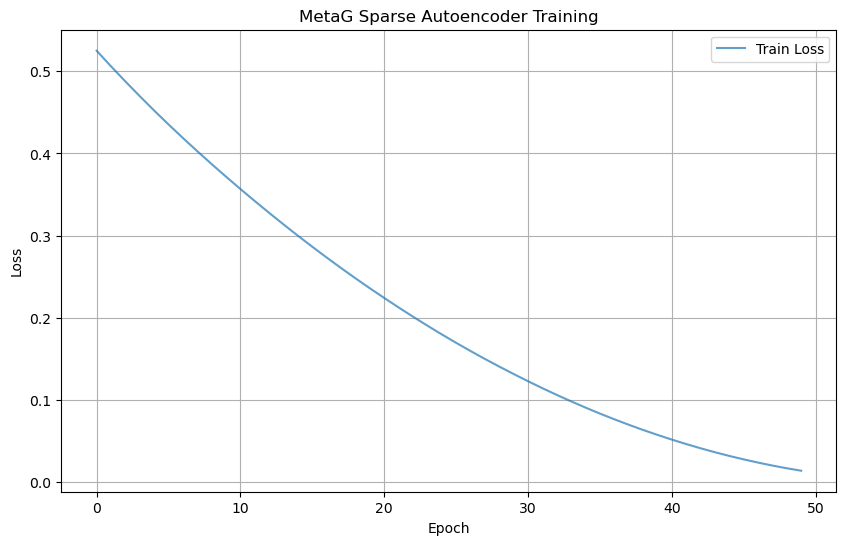

In [20]:
# Train sparse autoencoder on latent features
print("Training sparse autoencoder for MetaG...")
sparse_losses = extractor_metag.train_sparse_autoencoder(all_latent_metag, 
                                                       sparse_multiplier=3, 
                                                       epochs=50)

# Plot sparse autoencoder training curves
plot_training_curves(sparse_losses, [], "MetaG Sparse Autoencoder Training")



## Cell 20: Metagenomics Analysis - Extract Sparse Features


In [21]:
# Get sparse features
print("Extracting sparse features...")
sparse_features_metag = extractor_metag.get_sparse_features(all_latent_metag)

print(f"MetaG sparse features shape: {sparse_features_metag.shape}")
print(f"MetaG sparsity: {(sparse_features_metag == 0).mean()*100:.2f}%")
print(f"Non-zero features per sample (mean): {(sparse_features_metag != 0).sum(axis=1).mean():.2f}")
print(f"Feature activation statistics:")
print(f"  Mean: {sparse_features_metag.mean():.6f}")
print(f"  Std: {sparse_features_metag.std():.6f}")
print(f"  Min: {sparse_features_metag.min():.6f}")
print(f"  Max: {sparse_features_metag.max():.6f}")


Extracting sparse features...
MetaG sparse features shape: (741, 150)
MetaG sparsity: 0.00%
Non-zero features per sample (mean): 150.00
Feature activation statistics:
  Mean: 0.000510
  Std: 0.018676
  Min: -0.077685
  Max: 0.074628


In [22]:
print("Mapping MetaG sparse features back to original OTUs...")
metag_mapping_results = map_sparse_features_to_otus(
    extractor_metag, 
    sparse_features_metag, 
    processor.metag_data.columns,  # Original MetaG OTU IDs
    approach_name="MetaG"
)

Mapping MetaG sparse features back to original OTUs...

MAPPING SPARSE FEATURES TO OTUs - METAG
Sparsity of MetaG encoded features: 0.00%
Model architecture:
  Sparse AE encoder weights shape: (150, 50)
  VAE encoder (mu) weights shape: (50, 128)
  Sparse dimensions: 150
  Original gene/OTU count: 2123
Analyzing sparse feature importance...

Top OTUs/genes for most activated sparse features in MetaG:

Sparse feature 84 (activation: 0.0228):
  G003343565: 0.0080
  G000158275: 0.0078
  G001758045: 0.0075
  G001187865: 0.0068
  G000433355: 0.0067
  G000735365: 0.0066
  G000168835: 0.0064
  G000248015: 0.0063
  G000178255: 0.0063
  G000382425: 0.0063

Sparse feature 71 (activation: 0.0232):
  G900545715: 0.0112
  G001428745: 0.0092
  G000159435: 0.0088
  G900097105: 0.0088
  G001917125: 0.0086
  G001917295: 0.0081
  G000169655: 0.0080
  G902770605: 0.0078
  G000437915: 0.0072
  G000269605: 0.0071

Sparse feature 14 (activation: 0.0243):
  G000435155: 0.0082
  G000426745: 0.0082
  G00385270

## Cell 21: Metagenomics Analysis - Classification


METAGENOMICS QIIME2 CLASSIFICATION
Sparse training features shape: (592, 150)
Sparse test features shape: (149, 150)

DEBUGGING Q2 SAMPLE CLASSIFIER - METAG
Input data shapes:
  X_train: (592, 150)
  X_test: (149, 150)
  y_train: (592,)
  y_test: (149,)
  label_names: ['CD' 'UC' 'nonIBD']

Label distribution:
  y_train unique: (array([0, 1, 2]), array([273, 169, 150]))
  y_test unique: (array([0, 1, 2]), array([68, 43, 38]))
Converting metag features to QIIME2 format...

Combined data:
  X_combined shape: (741, 150)
  y_combined shape: (741,)
  y_combined unique: (array([0, 1, 2]), array([341, 212, 188]))

Sample IDs:
  Total samples: 741
  First 5 sample IDs: ['train_sample_0', 'train_sample_1', 'train_sample_2', 'train_sample_3', 'train_sample_4']
  Last 5 sample IDs: ['test_sample_144', 'test_sample_145', 'test_sample_146', 'test_sample_147', 'test_sample_148']

=== DEBUGGING BIOM/QZA CONVERSION ===
Input sparse_features shape: (741, 150)
Input sample_ids length: 741
Feature prefix:


BIOM table as DataFrame:
DataFrame shape: (741, 150)
DataFrame columns (first 5): ['metag_sparse_0', 'metag_sparse_1', 'metag_sparse_2', 'metag_sparse_3', 'metag_sparse_4']
DataFrame index (first 5): ['train_sample_0', 'train_sample_1', 'train_sample_2', 'train_sample_3', 'train_sample_4']
DataFrame preview:
                metag_sparse_0  metag_sparse_1  metag_sparse_2
train_sample_0       -0.021290         0.01929        0.020203
train_sample_1       -0.016490         0.01929        0.020203
train_sample_2       -0.009821         0.01929        0.020203

Converting to QIIME2 artifact...
QZA artifact created: <artifact: FeatureTable[Frequency] uuid: 63b8dd57-d194-4673-81e1-6f637cf5e93a>
QZA artifact type: FeatureTable[Frequency]
QZA artifact UUID: 63b8dd57-d194-4673-81e1-6f637cf5e93a

QZA artifact as DataFrame:
QZA DataFrame shape: (741, 150)
QZA DataFrame preview:
                metag_sparse_0  metag_sparse_1  metag_sparse_2
train_sample_0       -0.021290         0.01929        0.0

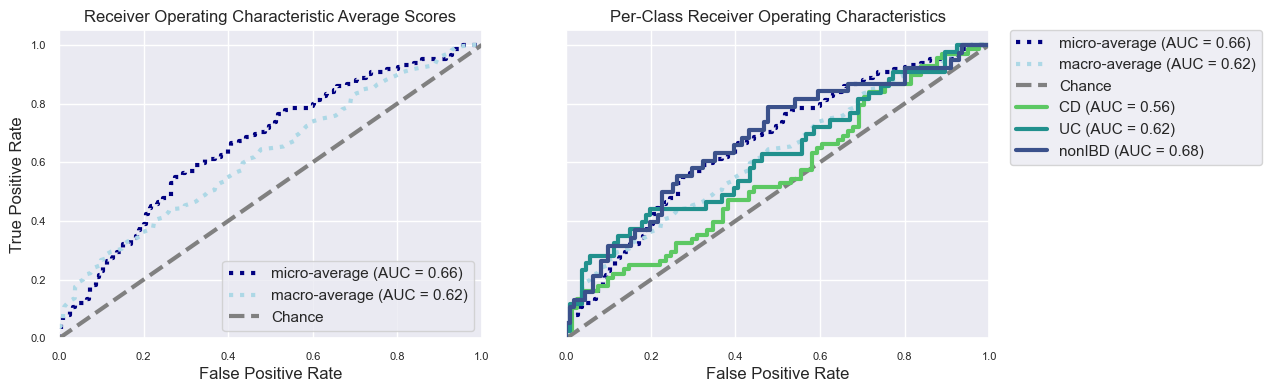

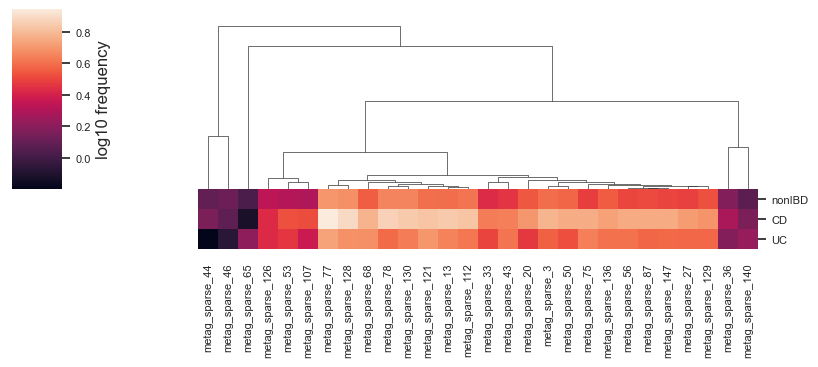

In [23]:
print("="*60)
print("METAGENOMICS QIIME2 CLASSIFICATION") 
print("="*60)

# Split sparse features for classification
X_train_sparse_metag, X_test_sparse_metag = train_test_split(
    sparse_features_metag, test_size=0.2, random_state=42, 
    stratify=processor.encoded_labels
)

print(f"Sparse training features shape: {X_train_sparse_metag.shape}")
print(f"Sparse test features shape: {X_test_sparse_metag.shape}")

# Train and evaluate with QIIME2 classifier
classifier_metag = Q2SampleClassifier()
results_metag = classifier_metag.train_and_evaluate(
    X_train_sparse_metag, X_test_sparse_metag, y_train, y_test, 
    processor.label_names, approach_name="metag"
)

print("MetaG QIIME2 classification completed!")



## Cell 22: Metagenomics Analysis - Visualization



Creating latent space visualizations...
Computing UMAP embedding...
Computing t-SNE embedding...


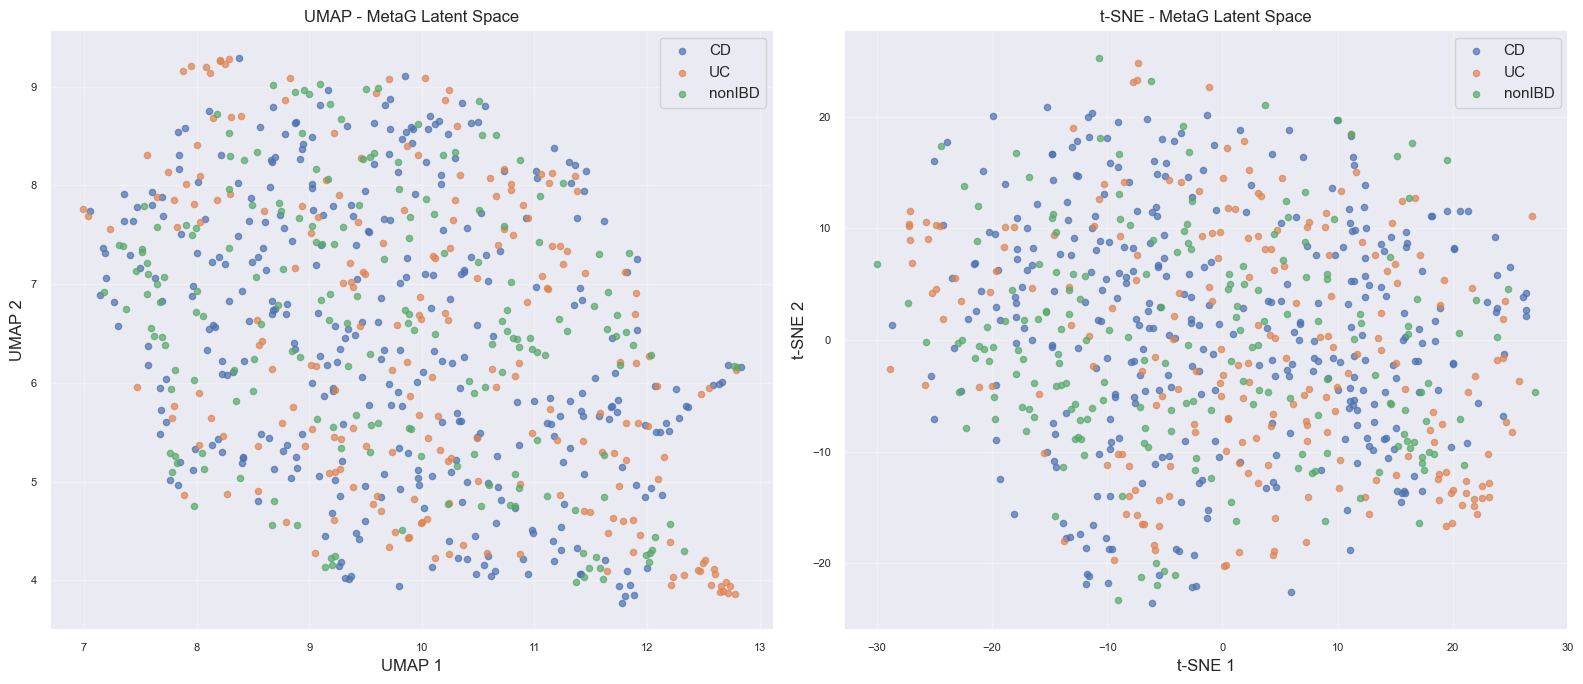

MetaG analysis completed!


In [24]:
# Visualize latent space
print("Creating latent space visualizations...")
vis_df_metag = visualize_latent_space(all_latent_metag, processor.encoded_labels, 
                      processor.label_names, "MetaG Latent Space")

print("MetaG analysis completed!")



## Cell 23: Metatranscriptomics Analysis - Data Preparation


In [25]:
print("\n" + "="*60)
print("METATRANSCRIPTOMICS ANALYSIS")
print("="*60)

# Prepare data loaders for MetaT
X_train_metaT, X_test_metaT, y_train, y_test = train_test_split(
    processor.metaT_scaled, processor.encoded_labels, 
    test_size=0.2, random_state=42, stratify=processor.encoded_labels
)

print(f"MetaT training set shape: {X_train_metaT.shape}")
print(f"MetaT test set shape: {X_test_metaT.shape}")

# Create PyTorch tensors and data loaders
train_tensor = torch.FloatTensor(X_train_metaT).to(device)
test_tensor = torch.FloatTensor(X_test_metaT).to(device)

train_dataset = TensorDataset(train_tensor)
test_dataset = TensorDataset(test_tensor)

# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=32)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

print("MetaT data loaders created successfully!")



METATRANSCRIPTOMICS ANALYSIS
MetaT training set shape: (592, 422)
MetaT test set shape: (149, 422)
MetaT data loaders created successfully!


## Cell 24: Metatranscriptomics Analysis - Train VAE


In [26]:
# Define the simplified VAE class
class SimpleMicrobiomeVAE(nn.Module):
    """Simplified VAE without batch normalization for smaller datasets"""
    
    def __init__(self, input_dim, hidden_dims=[200, 100, 50], latent_dim=25, dropout_rate=0.1):
        super(SimpleMicrobiomeVAE, self).__init__()
        
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        # Encoder without batch norm
        encoder_layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            encoder_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim
            
        self.encoder = nn.Sequential(*encoder_layers)
        
        # Latent projections
        self.fc_mu = nn.Linear(hidden_dims[-1], latent_dim)
        self.fc_var = nn.Linear(hidden_dims[-1], latent_dim)
        
        # Decoder without batch norm
        decoder_layers = []
        prev_dim = latent_dim
        
        for hidden_dim in reversed(hidden_dims):
            decoder_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim
            
        decoder_layers.append(nn.Linear(hidden_dims[0], input_dim))
        self.decoder = nn.Sequential(*decoder_layers)
        
        # Conservative weight initialization
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_var(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

print("SimpleMicrobiomeVAE defined successfully!")

SimpleMicrobiomeVAE defined successfully!


In [27]:
print(f"MetaT data stats:")
print(f"  Min: {X_train_metaT.min():.6f}")
print(f"  Max: {X_train_metaT.max():.6f}")
print(f"  Mean: {X_train_metaT.mean():.6f}")
print(f"  Std: {X_train_metaT.std():.6f}")
print(f"  NaN count: {np.isnan(X_train_metaT).sum()}")
print(f"  Inf count: {np.isinf(X_train_metaT).sum()}")

MetaT data stats:
  Min: -3.169552
  Max: 3.168176
  Mean: -0.002915
  Std: 1.002173
  NaN count: 0
  Inf count: 0


Creating VAE with input dimension: 422
VAE architecture created:
  Input dim: 422
  Hidden dims: [256, 128, 64]
  Latent dim: 32
Training VAE for 100 epochs with very conservative parameters...
Epoch 1: Train Loss: 1.004376, Val Loss: 0.987095
Epoch 10: Train Loss: 1.004267, Val Loss: 0.987521
Early stopping at epoch 16
Loaded best model weights
Training completed in 148.85 seconds


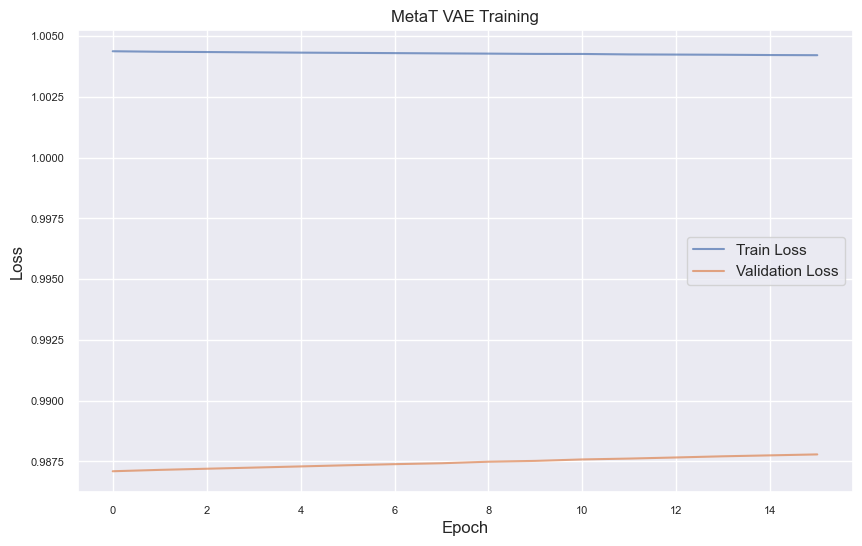

In [28]:
# Create and train VAE for MetaT
input_dim_metaT = X_train_metaT.shape[1]
print(f"Creating VAE with input dimension: {input_dim_metaT}")

# vae_metaT = MicrobiomeVAE(input_dim_metaT, hidden_dims=[256, 128, 64], 
#                           latent_dim=32).to(device)
vae_metaT = SimpleMicrobiomeVAE(input_dim_metaT, hidden_dims=[256, 128, 64], 
                          latent_dim=32).to(device)

print(f"VAE architecture created:")
print(f"  Input dim: {input_dim_metaT}")
print(f"  Hidden dims: [256, 128, 64]")
print(f"  Latent dim: 32")

# Train the VAE
trainer_metaT = MicrobiomeVAETrainer(vae_metaT, device)
train_losses, val_losses = trainer_metaT.train(train_loader, test_loader, epochs=100)

# Plot training curves
plot_training_curves(train_losses, val_losses, "MetaT VAE Training")



## Cell 25: Metatranscriptomics Analysis - Extract Features and Train SAE



Extracting latent features for all MetaT data...
Latent features shape: (741, 32)
Training sparse autoencoder for MetaT...
Training sparse autoencoder: 32 -> 96
Sparse AE Epoch 1: Loss: 0.270827
Sparse AE Epoch 10: Loss: 0.205947
Sparse AE Epoch 20: Loss: 0.146598
Sparse AE Epoch 30: Loss: 0.097537
Sparse AE Epoch 40: Loss: 0.058163
Sparse AE Epoch 50: Loss: 0.029079
Sparse autoencoder training completed with 50 valid epochs


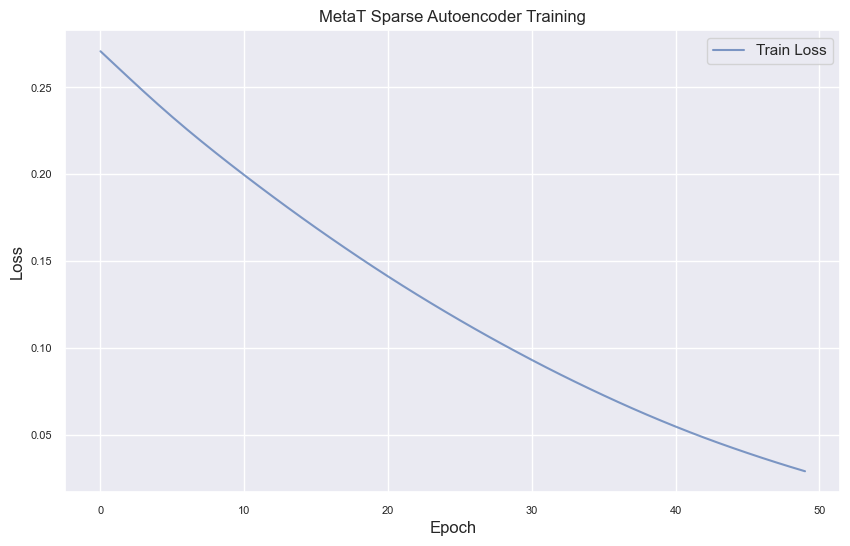

In [29]:
# Create feature extractor and get latent features
extractor_metaT = FeatureExtractor(vae_metaT, device)

print("Extracting latent features for all MetaT data...")
all_latent_metaT = extractor_metaT.get_latent_features(processor.metaT_scaled)

print(f"Latent features shape: {all_latent_metaT.shape}")

# Train sparse autoencoder
print("Training sparse autoencoder for MetaT...")
sparse_losses = extractor_metaT.train_sparse_autoencoder(all_latent_metaT, 
                                                       sparse_multiplier=3, 
                                                       epochs=50)

plot_training_curves(sparse_losses, [], "MetaT Sparse Autoencoder Training")

# Get sparse features
sparse_features_metaT = extractor_metaT.get_sparse_features(all_latent_metaT)


In [30]:

print(f"MetaT sparse features shape: {sparse_features_metaT.shape}")
print(f"MetaT sparsity: {(sparse_features_metaT == 0).mean()*100:.2f}%")


MetaT sparse features shape: (741, 96)
MetaT sparsity: 0.00%


In [31]:
print("Mapping MetaT sparse features back to original OTUs...")
metat_mapping_results = map_sparse_features_to_otus(
    extractor_metaT, 
    sparse_features_metaT, 
    processor.metaT_data.columns,  # Original MetaT OTU IDs
    approach_name="MetaT"
)

Mapping MetaT sparse features back to original OTUs...

MAPPING SPARSE FEATURES TO OTUs - METAT
Sparsity of MetaT encoded features: 0.00%
Model architecture:
  Sparse AE encoder weights shape: (96, 32)
  VAE encoder (mu) weights shape: (32, 64)
  Sparse dimensions: 96
  Original gene/OTU count: 422
Analyzing sparse feature importance...

Top OTUs/genes for most activated sparse features in MetaT:

Sparse feature 93 (activation: 0.0272):
  G000146185: 0.0188
  G000435395: 0.0130
  G000436395: 0.0126
  G900113595: 0.0103
  G001917295: 0.0094
  G000437075: 0.0083
  G000160055: 0.0082
  G003435865: 0.0081
  G001717135: 0.0080
  G001025175: 0.0076

Sparse feature 56 (activation: 0.0279):
  G900545235: 0.0109
  G000437075: 0.0101
  G004554925: 0.0099
  G000297775: 0.0093
  G001717135: 0.0086
  G900683765: 0.0083
  G000205025: 0.0082
  G003435865: 0.0081
  G000010425: 0.0075
  G000723465: 0.0067

Sparse feature 32 (activation: 0.0290):
  G900545235: 0.0110
  G000435395: 0.0110
  G012161415: 0


## Cell 26: Metatranscriptomics Analysis - Classification and Visualization


METATRANSCRIPTOMICS QIIME2 CLASSIFICATION

DEBUGGING Q2 SAMPLE CLASSIFIER - METAT
Input data shapes:
  X_train: (592, 96)
  X_test: (149, 96)
  y_train: (592,)
  y_test: (149,)
  label_names: ['CD' 'UC' 'nonIBD']

Label distribution:
  y_train unique: (array([0, 1, 2]), array([273, 169, 150]))
  y_test unique: (array([0, 1, 2]), array([68, 43, 38]))
Converting metat features to QIIME2 format...

Combined data:
  X_combined shape: (741, 96)
  y_combined shape: (741,)
  y_combined unique: (array([0, 1, 2]), array([341, 212, 188]))

Sample IDs:
  Total samples: 741
  First 5 sample IDs: ['train_sample_0', 'train_sample_1', 'train_sample_2', 'train_sample_3', 'train_sample_4']
  Last 5 sample IDs: ['test_sample_144', 'test_sample_145', 'test_sample_146', 'test_sample_147', 'test_sample_148']

=== DEBUGGING BIOM/QZA CONVERSION ===
Input sparse_features shape: (741, 96)
Input sample_ids length: 741
Feature prefix: metat_sparse_
Created 96 feature IDs
First 5 feature IDs: ['metat_sparse_0', '

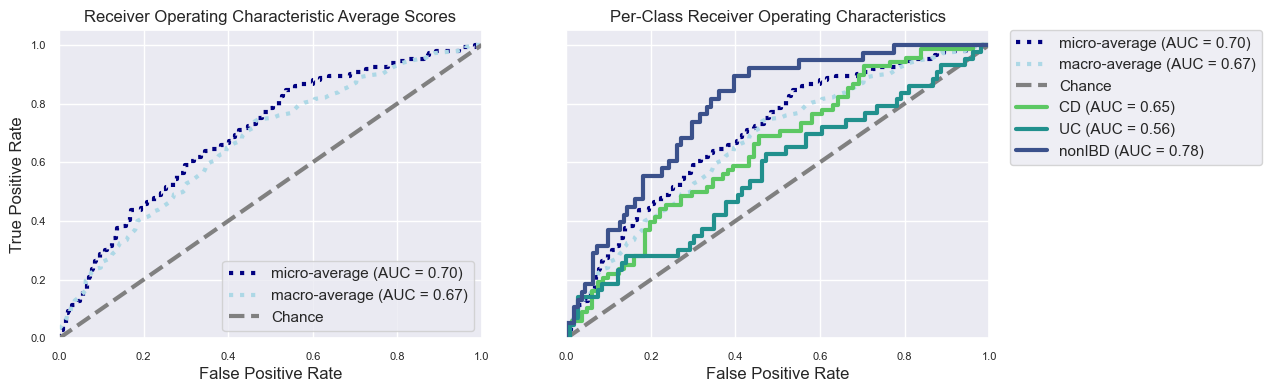

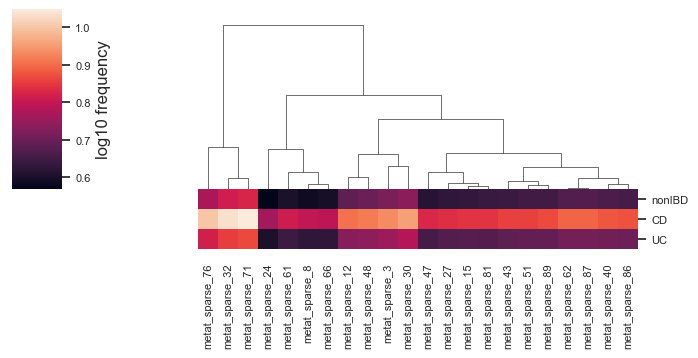

In [32]:
print("="*60)
print("METATRANSCRIPTOMICS QIIME2 CLASSIFICATION")
print("="*60)

# Split sparse features for classification
X_train_sparse_metaT, X_test_sparse_metaT = train_test_split(
    sparse_features_metaT, test_size=0.2, random_state=42, 
    stratify=processor.encoded_labels
)

# Train and evaluate with QIIME2 classifier
classifier_metaT = Q2SampleClassifier() 
results_metaT = classifier_metaT.train_and_evaluate(
    X_train_sparse_metaT, X_test_sparse_metaT, y_train, y_test, 
    processor.label_names, approach_name="metat"
)

print("MetaT QIIME2 classification completed!")


## Cell 29: Results Summary and Comparison (Modified)


In [33]:
print("\n" + "="*60)
print("RESULTS SUMMARY")
print("="*60)

# Note: QIIME2 results are stored differently, so we'll summarize differently
approaches = ['MetaG', 'MetaT']
all_results = [results_metag, results_metaT]

print("QIIME2 Classification Results Summary:")
print("="*50)

for approach, results in zip(approaches, all_results):
    print(f"\n{approach} Analysis:")
    for model_name, metrics in results.items():
        if 'error' not in metrics:
            print(f"  Model: {model_name}")
            print(f"  Status: Classification completed")
            print(f"  Accuracy file: q2_accuracy_{approach.lower()}.qzv")
            print(f"  Predictions file: q2_predictions_{approach.lower()}.qzv") 
            print(f"  Feature importance file: q2_feature_importance_{approach.lower()}.qza")
        else:
            print(f"  Model: {model_name}")
            print(f"  Status: Error - {metrics.get('error', 'Unknown error')}")

print(f"\nTo view detailed results:")
print("1. Use QIIME2 View (view.qiime2.org) to open .qzv files")
print("2. Load .qza files in QIIME2 for further analysis")
print("3. Compare accuracy metrics between MetaG and MetaT approaches")


RESULTS SUMMARY
QIIME2 Classification Results Summary:

MetaG Analysis:
  Model: GradientBoostingClassifier
  Status: Classification completed
  Accuracy file: q2_accuracy_metag.qzv
  Predictions file: q2_predictions_metag.qzv
  Feature importance file: q2_feature_importance_metag.qza

MetaT Analysis:
  Model: GradientBoostingClassifier
  Status: Classification completed
  Accuracy file: q2_accuracy_metat.qzv
  Predictions file: q2_predictions_metat.qzv
  Feature importance file: q2_feature_importance_metat.qza

To view detailed results:
1. Use QIIME2 View (view.qiime2.org) to open .qzv files
2. Load .qza files in QIIME2 for further analysis
3. Compare accuracy metrics between MetaG and MetaT approaches



## Cell 30: Feature Importance Analysis (Modified)



QIIME2 FEATURE IMPORTANCE ANALYSIS
Feature importance analysis is now handled by QIIME2.
Results are saved in the following files:
- q2_feature_importance_metag.qza
- q2_feature_importance_metat.qza
- q2_heatmap_metag.qzv
- q2_heatmap_metat.qzv

To analyze feature importance:
1. Load the .qza files in QIIME2
2. View the .qzv heatmap files in QIIME2 View
3. Export feature importance data for custom analysis if needed

=== DEBUGGING BIOM/QZA CONVERSION ===
Input sparse_features shape: (741, 150)
Input sample_ids length: 741
Feature prefix: metag_sparse_
Created 150 feature IDs
First 5 feature IDs: ['metag_sparse_0', 'metag_sparse_1', 'metag_sparse_2', 'metag_sparse_3', 'metag_sparse_4']
First 5 sample IDs: ['sample_0', 'sample_1', 'sample_2', 'sample_3', 'sample_4']

Sparse features statistics:
  Min value: -0.077685
  Max value: 0.074628
  Mean: 0.000510
  Std: 0.018676
  Zero values: 0 / 111150
  NaN values: 0
  Inf values: 0

Creating BIOM table...
Transposing features for BIOM: (150

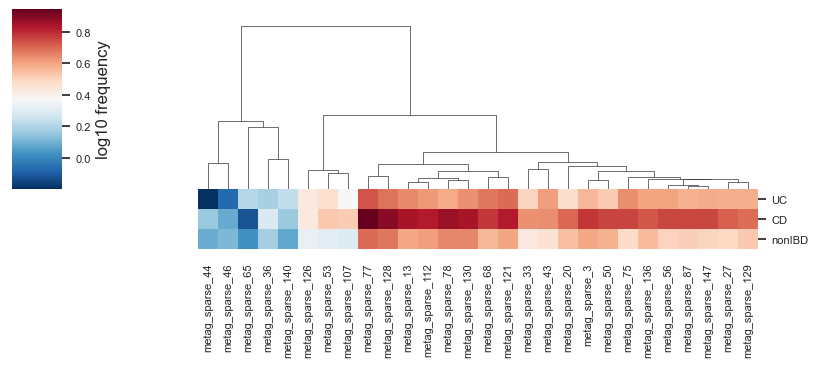

In [34]:
print("\n" + "="*60)
print("QIIME2 FEATURE IMPORTANCE ANALYSIS")
print("="*60)

print("Feature importance analysis is now handled by QIIME2.")
print("Results are saved in the following files:")
print("- q2_feature_importance_metag.qza")
print("- q2_feature_importance_metat.qza") 
print("- q2_heatmap_metag.qzv")
print("- q2_heatmap_metat.qzv")

print("\nTo analyze feature importance:")
print("1. Load the .qza files in QIIME2")
print("2. View the .qzv heatmap files in QIIME2 View")
print("3. Export feature importance data for custom analysis if needed")

# You can still create heatmaps if needed:
if 'classifier_metag' in locals() and classifier_metag.results:
    try:
        # Create sample metadata for heatmap
        sample_ids = [f"sample_{i}" for i in range(len(processor.encoded_labels))]
        metadata_df = pd.DataFrame({
            'sample-id': sample_ids,
            'diagnosis': [processor.label_names[label] for label in processor.encoded_labels]
        })
        metadata_df.set_index('sample-id', inplace=True)
        q2_metadata = Metadata(metadata_df)
        diagnosis_column = q2_metadata.get_column('diagnosis')
        
        # Create heatmap (example for MetaG)
        qza_table, _ = classifier_metag.sparse_features_to_biom_qza(
            sparse_features_metag, sample_ids, "metag_sparse_"
        )
        
        classifier_metag.create_heatmap(
            qza_table, 
            classifier_metag.results.feature_importance,
            diagnosis_column,
            "metag"
        )
    except Exception as e:
        print(f"Could not create heatmap: {str(e)}")

print("\nFeature importance analysis completed!")

In [35]:
def map_sparse_features_with_taxonomy(extractor, sparse_features, gene_names, taxonomy_df, approach_name="features"):
    """Enhanced mapping that includes taxonomy information"""
    
    print(f"\n{'='*60}")
    print(f"ENHANCED SPARSE-TO-OTU MAPPING WITH TAXONOMY - {approach_name.upper()}")
    print(f"{'='*60}")
    
    # Get the basic mapping first
    basic_results = map_sparse_features_to_otus(extractor, sparse_features, gene_names, approach_name)
    
    # Add taxonomy information to the results
    print(f"Adding taxonomy information...")
    
    enhanced_importance_list = []
    for _, row in basic_results['sparse_importance_df'].iterrows():
        gene_id = row['Gene_OTU']
        importance = row['Sparse_AE_Importance']
        
        # Get taxonomy if available
        if gene_id in taxonomy_df.index:
            taxonomy = taxonomy_df.loc[gene_id, 'taxonomy']
            # Extract species name using your existing function
            species_name = extract_species_name(taxonomy) if 'extract_species_name' in globals() else "Unknown"
        else:
            taxonomy = "Unknown taxonomy"
            species_name = "Unknown species"
        
        enhanced_importance_list.append({
            'Gene_OTU': gene_id,
            'Sparse_AE_Importance': importance,
            'Species': species_name,
            'Full_Taxonomy': taxonomy
        })
    
    # Create enhanced dataframe
    enhanced_importance_df = pd.DataFrame(enhanced_importance_list)
    
    print(f"\nTop 20 OTUs/genes with taxonomy in {approach_name}:")
    print(enhanced_importance_df.head(20)[['Gene_OTU', 'Sparse_AE_Importance', 'Species']])
    
    # Save enhanced results
    enhanced_output_file = f'sparse_importance_with_taxonomy_{approach_name.lower()}.csv'
    enhanced_importance_df.to_csv(enhanced_output_file, index=False)
    print(f"Enhanced results saved to {enhanced_output_file}")
    
    # Show top species
    print(f"\nTop species by importance in {approach_name}:")
    species_importance = enhanced_importance_df.groupby('Species')['Sparse_AE_Importance'].sum().sort_values(ascending=False)
    print(species_importance.head(10))
    
    return enhanced_importance_df


In [36]:

# Run enhanced analysis if taxonomy is available
if hasattr(processor, 'metag_taxonomy'):
    print("Running enhanced MetaG analysis with taxonomy...")
    metag_taxonomy_indexed = processor.metag_taxonomy.set_index('genome_id')
    enhanced_metag_results = map_sparse_features_with_taxonomy(
        extractor_metag, 
        sparse_features_metag, 
        processor.metag_data.columns,
        metag_taxonomy_indexed,
        approach_name="MetaG"
    )


Running enhanced MetaG analysis with taxonomy...

ENHANCED SPARSE-TO-OTU MAPPING WITH TAXONOMY - METAG

MAPPING SPARSE FEATURES TO OTUs - METAG
Sparsity of MetaG encoded features: 0.00%
Model architecture:
  Sparse AE encoder weights shape: (150, 50)
  VAE encoder (mu) weights shape: (50, 128)
  Sparse dimensions: 150
  Original gene/OTU count: 2123
Analyzing sparse feature importance...

Top OTUs/genes for most activated sparse features in MetaG:

Sparse feature 84 (activation: 0.0228):
  G003343565: 0.0080
  G000158275: 0.0078
  G001758045: 0.0075
  G001187865: 0.0068
  G000433355: 0.0067
  G000735365: 0.0066
  G000168835: 0.0064
  G000248015: 0.0063
  G000178255: 0.0063
  G000382425: 0.0063

Sparse feature 71 (activation: 0.0232):
  G900545715: 0.0112
  G001428745: 0.0092
  G000159435: 0.0088
  G900097105: 0.0088
  G001917125: 0.0086
  G001917295: 0.0081
  G000169655: 0.0080
  G902770605: 0.0078
  G000437915: 0.0072
  G000269605: 0.0071

Sparse feature 14 (activation: 0.0243):
  G00

In [37]:

if hasattr(processor, 'metaT_taxonomy'):
    print("Running enhanced MetaT analysis with taxonomy...")
    metat_taxonomy_indexed = processor.metaT_taxonomy.set_index('genome_id')
    enhanced_metat_results = map_sparse_features_with_taxonomy(
        extractor_metaT, 
        sparse_features_metaT, 
        processor.metaT_data.columns,
        metat_taxonomy_indexed,
        approach_name="MetaT"
    )


Running enhanced MetaT analysis with taxonomy...

ENHANCED SPARSE-TO-OTU MAPPING WITH TAXONOMY - METAT

MAPPING SPARSE FEATURES TO OTUs - METAT
Sparsity of MetaT encoded features: 0.00%
Model architecture:
  Sparse AE encoder weights shape: (96, 32)
  VAE encoder (mu) weights shape: (32, 64)
  Sparse dimensions: 96
  Original gene/OTU count: 422
Analyzing sparse feature importance...

Top OTUs/genes for most activated sparse features in MetaT:

Sparse feature 93 (activation: 0.0272):
  G000146185: 0.0188
  G000435395: 0.0130
  G000436395: 0.0126
  G900113595: 0.0103
  G001917295: 0.0094
  G000437075: 0.0083
  G000160055: 0.0082
  G003435865: 0.0081
  G001717135: 0.0080
  G001025175: 0.0076

Sparse feature 56 (activation: 0.0279):
  G900545235: 0.0109
  G000437075: 0.0101
  G004554925: 0.0099
  G000297775: 0.0093
  G001717135: 0.0086
  G900683765: 0.0083
  G000205025: 0.0082
  G003435865: 0.0081
  G000010425: 0.0075
  G000723465: 0.0067

Sparse feature 32 (activation: 0.0290):
  G900545

In [38]:
# Simple OTU lookup in taxonomy dataframe
target_otus = ['G000183345', 'G000431575', 'G000434855', 'G000168835', 'G000009065']

print("Looking up specific OTUs in taxonomy dataframe:")
print("-" * 50)

for otu in target_otus:
   if hasattr(processor, 'metag_taxonomy'):
       metag_match = processor.metag_taxonomy[processor.metag_taxonomy['genome_id'] == otu]
       if not metag_match.empty:
           print(f"{otu} (MetaG): {metag_match['taxonomy'].iloc[0]}")
       else:
           print(f"{otu} (MetaG): Not found")
   
   if hasattr(processor, 'metaT_taxonomy'):
       metat_match = processor.metaT_taxonomy[processor.metaT_taxonomy['genome_id'] == otu]
       if not metat_match.empty:
           print(f"{otu} (MetaT): {metat_match['taxonomy'].iloc[0]}")
       else:
           print(f"{otu} (MetaT): Not found")
   
   print()

Looking up specific OTUs in taxonomy dataframe:
--------------------------------------------------
G000183345 (MetaG): d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Enterobacterales; f__Enterobacteriaceae; g__Escherichia; s__Escherichia coli
G000183345 (MetaT): d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Enterobacterales; f__Enterobacteriaceae; g__Escherichia; s__Escherichia coli

G000431575 (MetaG): d__Bacteria; p__Firmicutes_A; c__Clostridia; o__Oscillospirales; f__Oscillospiraceae; g__CAG-83; s__CAG-83 sp000431575
G000431575 (MetaT): d__Bacteria; p__Firmicutes_A; c__Clostridia; o__Oscillospirales; f__Oscillospiraceae; g__CAG-83; s__CAG-83 sp000431575

G000434855 (MetaG): d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Burkholderiales; f__Burkholderiaceae; g__Duodenibacillus; s__Duodenibacillus massiliensis
G000434855 (MetaT): d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Burkholderiales; f__Burkholderiaceae; g__Duodenibacillus; s__

In [39]:
def visualize_sparse_mappings(mapping_results, approach_name="features"):
    """Visualize the sparse feature mappings"""
    
    print(f"Creating visualizations for {approach_name} sparse mappings...")
    
    # Plot 1: Feature activation distribution
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Sparsity histogram
    activations = mapping_results['feature_activations']
    axes[0, 0].hist(activations, bins=50, alpha=0.7, color='skyblue')
    axes[0, 0].set_title(f'{approach_name} Feature Activation Distribution')
    axes[0, 0].set_xlabel('Mean Activation')
    axes[0, 0].set_ylabel('Frequency')
    
    # Top 20 most important OTUs
    top_20 = mapping_results['sparse_importance_df'].head(20)
    axes[0, 1].barh(range(len(top_20)), top_20['Sparse_AE_Importance'])
    axes[0, 1].set_yticks(range(len(top_20)))
    axes[0, 1].set_yticklabels([f"{otu[:15]}..." if len(otu) > 15 else otu for otu in top_20['Gene_OTU']])
    axes[0, 1].set_title(f'Top 20 Most Important {approach_name} OTUs')
    axes[0, 1].set_xlabel('Importance Score')
    
    # Sparsity level
    sparsity = mapping_results['sparsity']
    axes[1, 0].pie([sparsity, 100-sparsity], labels=[f'Zero ({sparsity:.1f}%)', f'Non-zero ({100-sparsity:.1f}%)'], 
                   autopct='%1.1f%%', startangle=90)
    axes[1, 0].set_title(f'{approach_name} Feature Sparsity')
    
    # Feature importance distribution
    importance_values = mapping_results['sparse_importance_df']['Sparse_AE_Importance']
    axes[1, 1].hist(importance_values, bins=50, alpha=0.7, color='lightcoral')
    axes[1, 1].set_title(f'{approach_name} OTU Importance Distribution')
    axes[1, 1].set_xlabel('Importance Score')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_yscale('log')
    
    plt.tight_layout()
    plt.savefig(f'sparse_mapping_analysis_{approach_name.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()


Creating visualizations for MetaG sparse mappings...


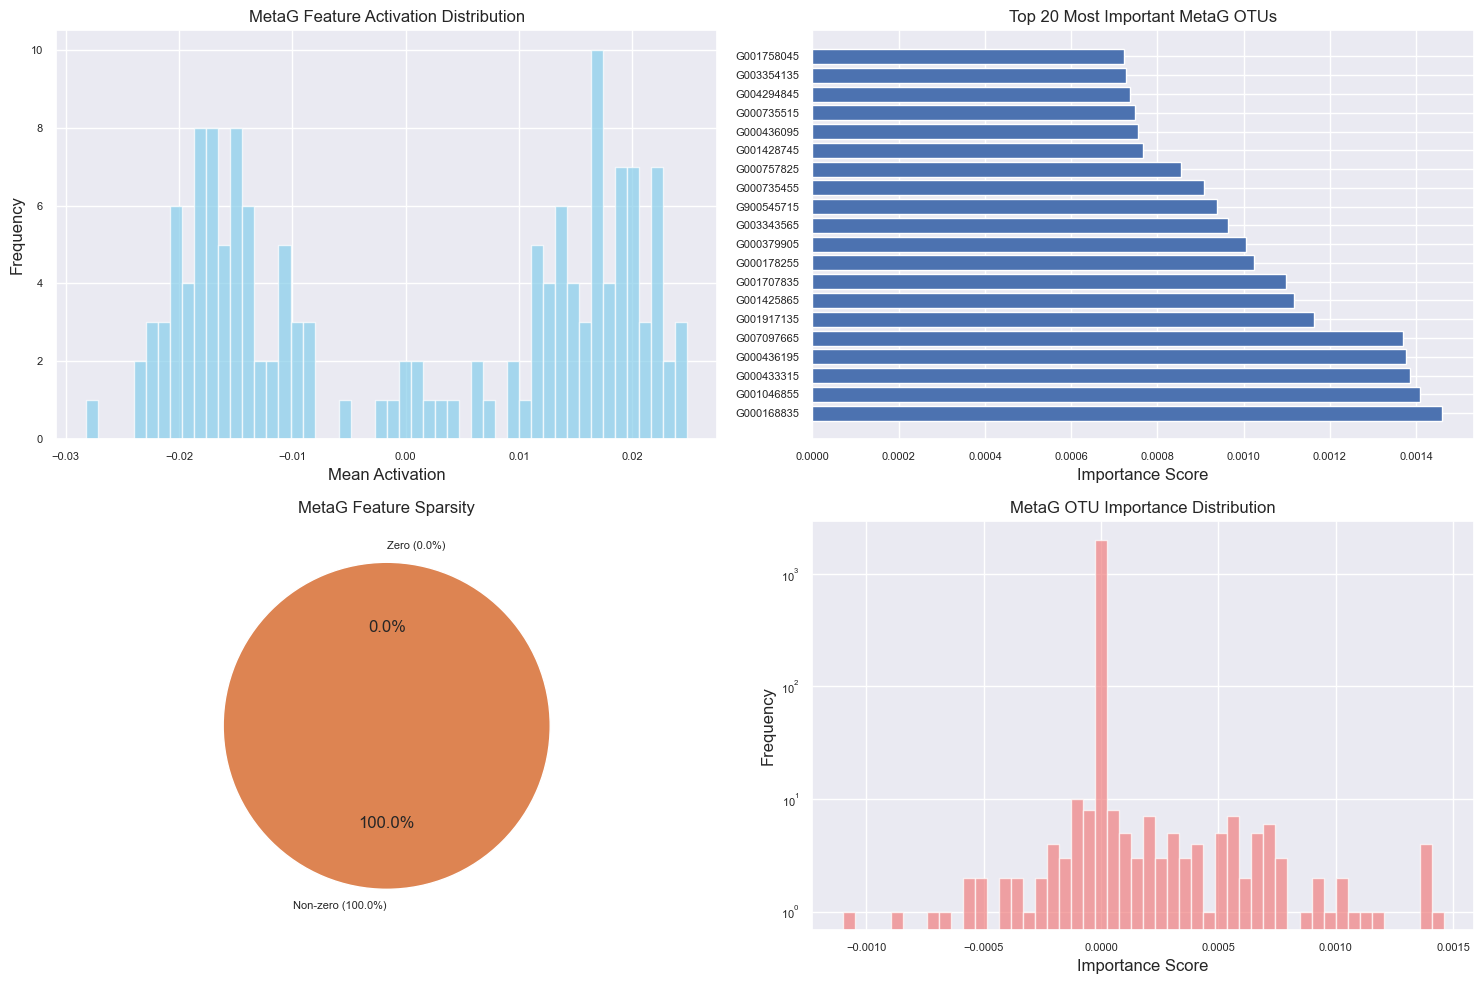

In [40]:

# Create visualizations
visualize_sparse_mappings(metag_mapping_results, "MetaG")


Creating visualizations for MetaT sparse mappings...


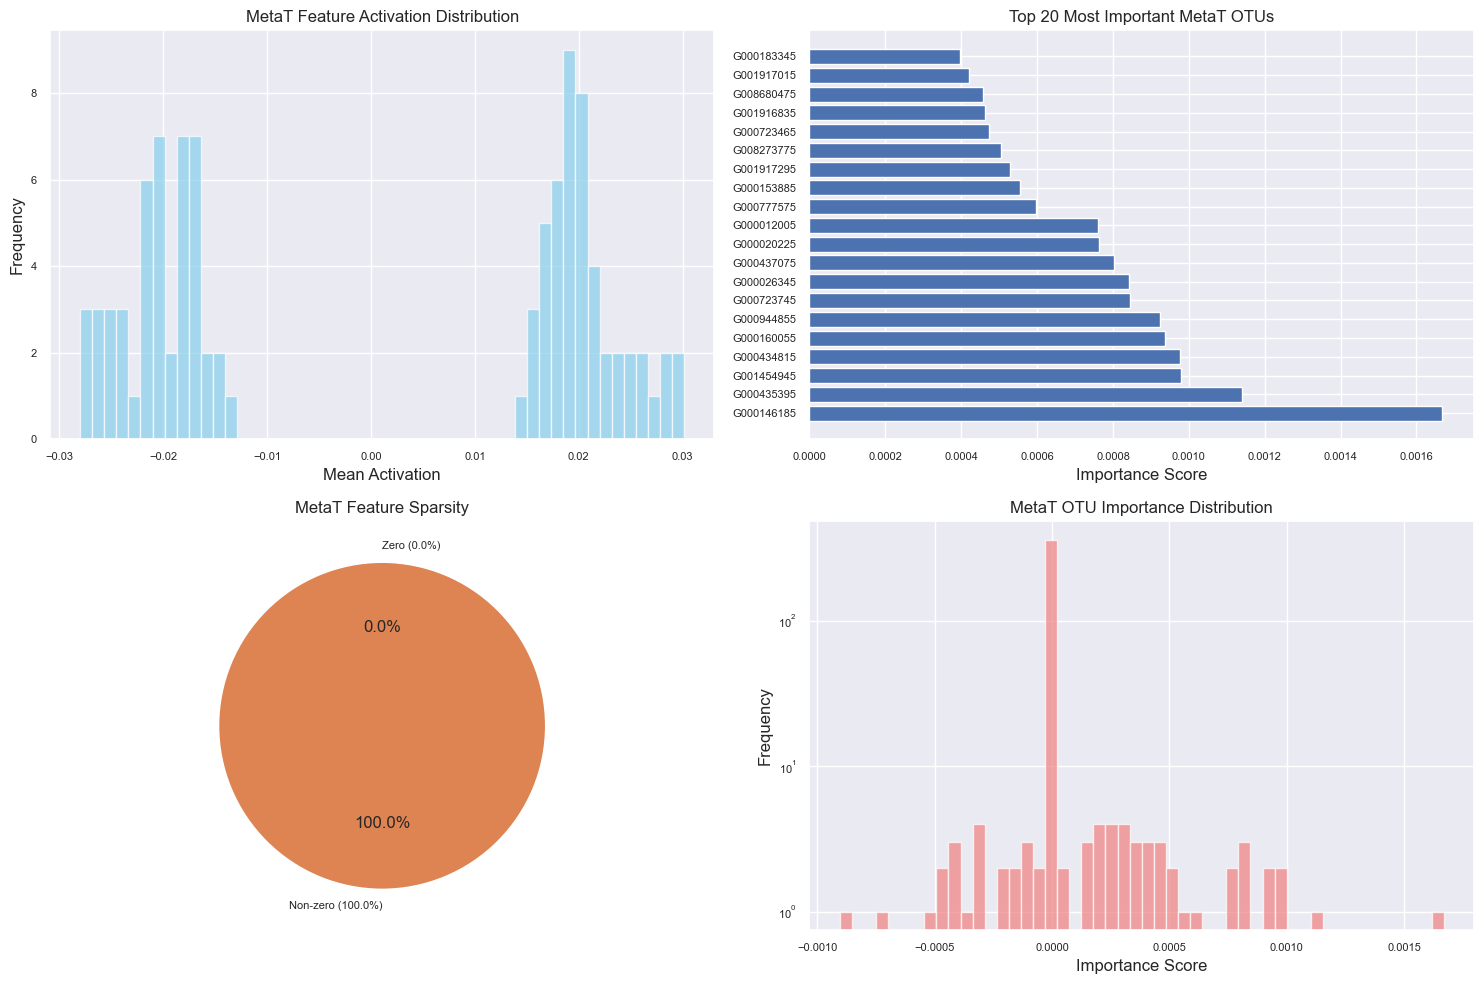


🎉 Sparse feature to OTU mapping completed for both MetaG and MetaT!
Files generated:
  - sparse_importance_metag.csv
  - sparse_importance_metat.csv
  - sparse_importance_with_taxonomy_metag.csv (if taxonomy available)
  - sparse_importance_with_taxonomy_metat.csv (if taxonomy available)
  - sparse_mapping_analysis_metag.png
  - sparse_mapping_analysis_metat.png


In [41]:

visualize_sparse_mappings(metat_mapping_results, "MetaT")

print("\n🎉 Sparse feature to OTU mapping completed for both MetaG and MetaT!")
print("Files generated:")
print("  - sparse_importance_metag.csv")
print("  - sparse_importance_metat.csv")  
print("  - sparse_importance_with_taxonomy_metag.csv (if taxonomy available)")
print("  - sparse_importance_with_taxonomy_metat.csv (if taxonomy available)")
print("  - sparse_mapping_analysis_metag.png")
print("  - sparse_mapping_analysis_metat.png")


## Cell 31: Data Quality and Model Diagnostics (Modified)


In [42]:

print("\n" + "="*60)
print("DATA QUALITY AND MODEL DIAGNOSTICS")
print("="*60)

# Data quality summary
print("Data Quality Summary:")
print(f"Total samples: {len(processor.common_samples)}")
print(f"MetaG features (filtered): {processor.metag_scaled.shape[1]}")
print(f"MetaT features (filtered): {processor.metaT_scaled.shape[1]}")

# Class distribution
print(f"\nClass distribution:")
for i, label in enumerate(processor.label_names):
    count = np.sum(processor.encoded_labels == i)
    print(f"  {label}: {count} ({count/len(processor.encoded_labels)*100:.1f}%)")

# Model diagnostics
print(f"\nModel Architecture Summary:")
print(f"VAE Latent Dimensions:")
print(f"  MetaG: {vae_metag.latent_dim}")
print(f"  MetaT: {vae_metaT.latent_dim}")

# Feature sparsity analysis
sparsity_data = []
if 'sparse_features_metag' in locals():
    sparsity_data.append(['MetaG', (sparse_features_metag == 0).mean() * 100])
if 'sparse_features_metaT' in locals():
    sparsity_data.append(['MetaT', (sparse_features_metaT == 0).mean() * 100])

if sparsity_data:
    sparsity_df = pd.DataFrame(sparsity_data, columns=['Approach', 'Sparsity (%)'])
    print(f"\nSparse Feature Statistics:")
    print(sparsity_df.to_string(index=False, float_format='%.2f'))

# Training convergence check
print(f"\nTraining Convergence Analysis:")
if len(train_losses) > 10:
    final_losses = train_losses[-10:]
    loss_std = np.std(final_losses)
    print(f"  Final 10 epochs loss std: {loss_std:.6f}")
    if loss_std < 0.01:
        print("  ✓ Training appears converged")
    else:
        print("  ⚠ Training may not have fully converged")
else:
    print("  Insufficient training epochs for convergence analysis")




DATA QUALITY AND MODEL DIAGNOSTICS
Data Quality Summary:
Total samples: 741
MetaG features (filtered): 2123
MetaT features (filtered): 422

Class distribution:
  CD: 341 (46.0%)
  UC: 212 (28.6%)
  nonIBD: 188 (25.4%)

Model Architecture Summary:
VAE Latent Dimensions:
  MetaG: 50
  MetaT: 32

Sparse Feature Statistics:
Approach  Sparsity (%)
   MetaG          0.00
   MetaT          0.00

Training Convergence Analysis:
  Final 10 epochs loss std: 0.000028
  ✓ Training appears converged



## Cell 32: Save Results and Models (Modified)


In [43]:
print("\n" + "="*60)
print("SAVING RESULTS AND MODELS")
print("="*60)

# Create results dictionary (modified for QIIME2)
pipeline_results = {
    'processor': processor,
    'results_metag': results_metag,
    'results_metaT': results_metaT,
    'models': {
        'vae_metag': vae_metag,
        'vae_metaT': vae_metaT
    },
    'extractors': {
        'extractor_metag': extractor_metag,
        'extractor_metaT': extractor_metaT
    }
}

# Save model states
print("Saving VAE model states...")
torch.save(vae_metag.state_dict(), 'vae_metag_final.pt')
torch.save(vae_metaT.state_dict(), 'vae_metaT_final.pt')

# Save sparse features
print("Saving sparse features...")
np.save('sparse_features_metag.npy', sparse_features_metag)
np.save('sparse_features_metaT.npy', sparse_features_metaT)

# Save latent representations
print("Saving latent representations...")
np.save('latent_metag.npy', all_latent_metag)
np.save('latent_metaT.npy', all_latent_metaT)

print("All results and models saved successfully!")
print("\nQIIME2 results are saved as:")
print("- q2_accuracy_*.qzv (view with QIIME2 View)")
print("- q2_predictions_*.qzv (view with QIIME2 View)")
print("- q2_feature_importance_*.qza (load in QIIME2)")
print("- q2_heatmap_*.qzv (view with QIIME2 View)")


SAVING RESULTS AND MODELS
Saving VAE model states...
Saving sparse features...
Saving latent representations...
All results and models saved successfully!

QIIME2 results are saved as:
- q2_accuracy_*.qzv (view with QIIME2 View)
- q2_predictions_*.qzv (view with QIIME2 View)
- q2_feature_importance_*.qza (load in QIIME2)
- q2_heatmap_*.qzv (view with QIIME2 View)


# Debug

In [44]:
#debug rclr to see if there are 0's post rclr and filtering